# **Analyse PESTEL de l’exportation de volaille française : préparation et exploration des données**

## En-tête / Introduction 

#### 🎯 Objectif du notebook

Ce notebook a pour objectif d'explorer les premières données fournies par la FAO afin de comprendre leur structure, leur contenu et leur potentiel pour l'étude de marché. Cette étape d'exploration permettra d’identifier les informations déjà disponibles et de déterminer quelles données complémentaires seront nécessaires pour construire une analyse plus complète dans le cadre du projet d’expansion internationale de l’entreprise.
Ensuite, ce seront les données récupérées sur des sources ouvertes (FAO, World Bank, etc.), qui seront préparées et nettoyées, en vu de tout regrouper sur un même fichiers, qui pourra ensuite être utiliser pour nos analyses.

#### 🌍 Contexte du projet

La Poule qui Chante est une entreprise française spécialisée dans l’élevage et la vente de poulets biologiques. L’entreprise souhaite évaluer les opportunités d’expansion à l’international. Ce projet consiste à produire une étude de marché, basée sur des données ouvertes, pour identifier des groupes de pays cibles pertinents. La première étape consiste à explorer les données fournies par la FAO, avant d’enrichir l’analyse avec des variables économiques, sociétales, environnementales ou politiques selon une approche PESTEL.

In [1]:
# 📦 Chargement des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# ⚙️ Configuration
%matplotlib inline
warnings.filterwarnings('ignore')        # Ignore les avertissements pour garder le notebook lisible
pd.set_option('display.max_rows', None)  # Afficher toutes les lignes si besoin
pd.set_option('display.width', None)     # Largeur d'affichage illimitée
sns.set(style="whitegrid")               # Style visuel pour seaborn

#### 🧭 Qu’est-ce qu’une analyse PESTEL ?

L’analyse PESTEL est un cadre d’analyse stratégique qui permet d’identifier les facteurs macro-environnementaux influençant un marché ou un projet d’entreprise. Elle est particulièrement utile pour évaluer un potentiel de développement international. L'acronyme signifie :

  P	  =  Politique	
  
  E	  =  Économique	 
  
  S	  =  Socioculturel	
  
  T	  =  Technologique
  
  E	  =  Environnemental	
  
  L	  =  Légal	    

# Partie 1 : Exploration initiale des données

## 1. Chargement des données

In [2]:
# Chargement des fichiers CSV dans des DataFrames

population_df = pd.read_csv("Population_2000_2018.csv", sep=",")
dispoalimentaire_df = pd.read_csv("DisponibiliteAlimentaire_2017.csv", sep=",")

In [3]:
# Affichage d'un aperçu de chaque jeu de données

print("✅ Population_2000_2018.csv :")
display(population_df.head())

print("✅ DisponibiliteAlimentaire_2017.csv :")
display(dispoalimentaire_df.head())

✅ Population_2000_2018.csv :


,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole,Note
0,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2000,2000,1000 personnes,20779.953,X,Sources internationales sûres,NaN
1,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2001,2001,1000 personnes,21606.988,X,Sources internationales sûres,NaN
2,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2002,2002,1000 personnes,22600.770,X,Sources internationales sûres,NaN
3,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2003,2003,1000 personnes,23680.871,X,Sources internationales sûres,NaN
4,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2004,2004,1000 personnes,24726.684,X,Sources internationales sûres,NaN


✅ DisponibiliteAlimentaire_2017.csv :


,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole
0,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5511,Production,2511,Blé et produits,2017,2017,Milliers de tonnes,4281.0,S,Données standardisées
1,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5611,Importations - Quantité,2511,Blé et produits,2017,2017,Milliers de tonnes,2302.0,S,Données standardisées
2,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5072,Variation de stock,2511,Blé et produits,2017,2017,Milliers de tonnes,-119.0,S,Données standardisées
3,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5911,Exportations - Quantité,2511,Blé et produits,2017,2017,Milliers de tonnes,0.0,S,Données standardisées
4,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5301,Disponibilité intérieure,2511,Blé et produits,2017,2017,Milliers de tonnes,6701.0,S,Données standardisées


## 2. Dictionnaire de données simplifié

In [4]:
# population_df

population_df.info()
population_df.describe()
population_df.nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4411 entries, 0 to 4410
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Code Domaine            4411 non-null   object 
 1   Domaine                 4411 non-null   object 
 2   Code zone               4411 non-null   int64  
 3   Zone                    4411 non-null   object 
 4   Code Élément            4411 non-null   int64  
 5   Élément                 4411 non-null   object 
 6   Code Produit            4411 non-null   int64  
 7   Produit                 4411 non-null   object 
 8   Code année              4411 non-null   int64  
 9   Année                   4411 non-null   int64  
 10  Unité                   4411 non-null   object 
 11  Valeur                  4411 non-null   float64
 12  Symbole                 4411 non-null   object 
 13  Description du Symbole  4411 non-null   object 
 14  Note                    258 non-null    

Code Domaine                 1
Domaine                      1
Code zone                  238
Zone                       238
Code Élément                 1
Élément                      1
Code Produit                 1
Produit                      1
Code année                  19
Année                       19
Unité                        1
Valeur                    4398
Symbole                      2
Description du Symbole       2
Note                         1
dtype: int64

In [5]:
# dispoalimentaire_df

dispoalimentaire_df.info()
dispoalimentaire_df.describe()
dispoalimentaire_df.nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 176600 entries, 0 to 176599
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Code Domaine            176600 non-null  object 
 1   Domaine                 176600 non-null  object 
 2   Code zone               176600 non-null  int64  
 3   Zone                    176600 non-null  object 
 4   Code Élément            176600 non-null  int64  
 5   Élément                 176600 non-null  object 
 6   Code Produit            176600 non-null  int64  
 7   Produit                 176600 non-null  object 
 8   Code année              176600 non-null  int64  
 9   Année                   176600 non-null  int64  
 10  Unité                   176600 non-null  object 
 11  Valeur                  176600 non-null  float64
 12  Symbole                 176600 non-null  object 
 13  Description du Symbole  176600 non-null  object 
dtypes: float64(1), int64

Code Domaine                 1
Domaine                      1
Code zone                  174
Zone                       174
Code Élément                17
Élément                     17
Code Produit                98
Produit                     98
Code année                   1
Année                        1
Unité                        4
Valeur                    7250
Symbole                      2
Description du Symbole       2
dtype: int64

## 3. Analyse de la population par pays et année

In [6]:
# Liste des années présentes dans les données
population_df['Année'].value_counts().sort_index()

Année
2000    229
2001    229
2002    229
2003    229
2004    229
2005    229
2006    230
2007    230
2008    230
2009    230
2010    230
2011    235
2012    236
2013    236
2014    236
2015    236
2016    236
2017    236
2018    236
Name: count, dtype: int64

### Prétraitement du fichier `population_df` : sélection de l’année 2017

Le fichier `dispoaliemntaire_df`, l’un des deux fichiers initiaux fournis pour ce projet, ne contient des données que pour **l’année 2017**. Dans un souci de cohérence avec ce fichier de référence, j'ai décidé d’aligner l’ensemble de notre jeu de données final sur **cette même année**.

##### Objectif : homogénéité temporelle

Étant donné que ce fichier fait partie du cœur de notre analyse, j'ai choisi de :
- **Limiter les autres sources de données à l’année 2017 uniquement**,
- **Supprimer les autres années** dans les fichiers issus d’API (Banque mondiale, FAO, etc.),
- **Aligner l’ensemble des indicateurs sur cette seule année**, afin d’éviter les décalages temporels entre variables.

##### Pourquoi ce choix est pertinent

- Cela garantit une **comparaison pertinente entre pays**, à un instant donné.
- L’analyse demandée (ACP + clustering) se concentre sur une **photographie des pays**, pas sur une évolution temporelle.
- Cela permet de **limiter le nombre de valeurs manquantes** dans la base finale, ce qui est crucial pour les méthodes multivariées.
- C’est **compatible avec la structure du fichier `population_df`**, qui aurait sinon été isolé du reste de l’analyse.

##### Conséquence

Les données de population pour chaque pays sont donc extraites uniquement pour **2017**, ce qui servira de base à l’un des indicateurs de notre analyse finale.

In [7]:
# Filtrer sur l'année 2017
population_df = population_df[population_df["Année"] == 2017]

# Supprimer la colonne "Année"
population_df = population_df.drop(columns=["Année"])

# Vérification
population_df.head()

,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Unité,Valeur,Symbole,Description du Symbole,Note
17,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2017,1000 personnes,36296.113,X,Sources internationales sûres,NaN
36,OA,Séries temporelles annuelles,202,Afrique du Sud,511,Population totale,3010,Population-Estimations,2017,1000 personnes,57009.756,X,Sources internationales sûres,NaN
55,OA,Séries temporelles annuelles,3,Albanie,511,Population totale,3010,Population-Estimations,2017,1000 personnes,2884.169,X,Sources internationales sûres,NaN
74,OA,Séries temporelles annuelles,4,Algérie,511,Population totale,3010,Population-Estimations,2017,1000 personnes,41389.189,X,Sources internationales sûres,NaN
93,OA,Séries temporelles annuelles,79,Allemagne,511,Population totale,3010,Population-Estimations,2017,1000 personnes,82658.409,X,Sources internationales sûres,NaN


In [8]:
# Trier les pays par population décroissante
top10_pop = population_df.sort_values(by='Valeur', ascending=False).head(10)

# Afficher le top 10
top10_pop[['Zone', 'Valeur']]

,Zone,Valeur
823,"Chine, continentale",1421021.791
1952,Inde,1338676.785
1230,États-Unis d'Amérique,325084.756
1971,Indonésie,264650.963
3029,Pakistan,207906.209
595,Brésil,207833.823
2877,Nigéria,190873.244
378,Bangladesh,159685.424
1268,Fédération de Russie,145530.082
2123,Japon,127502.725


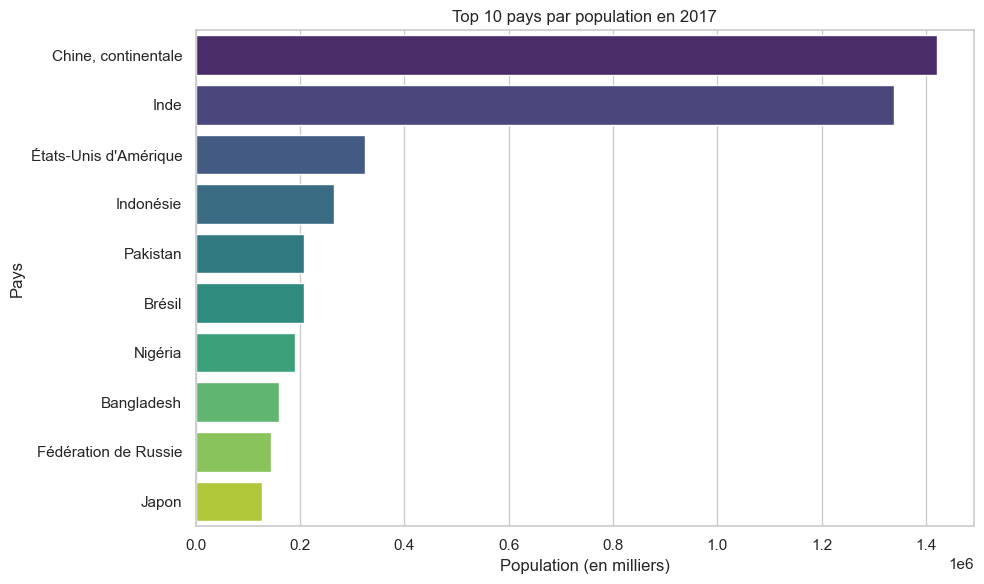

In [9]:
# Barplot de la population pour les 10 pays les plus peuplés
plt.figure(figsize=(10, 6))
sns.barplot(data=top10_pop, x='Valeur', y='Zone', palette='viridis')
plt.title("Top 10 pays par population en 2017")
plt.xlabel("Population (en milliers)")
plt.ylabel("Pays")
plt.tight_layout()
plt.show()

In [10]:
# Population totale couverte dans les données
total_pop = population_df['Valeur'].sum()

# Affichage des 10 premiers pays + leur part relative
top10_pop['Part (%)'] = (top10_pop['Valeur'] / total_pop) * 100
top10_pop[['Zone', 'Valeur', 'Part (%)']]

,Zone,Valeur,Part (%)
823,"Chine, continentale",1421021.791,18.826133
1952,Inde,1338676.785,17.735201
1230,États-Unis d'Amérique,325084.756,4.306823
1971,Indonésie,264650.963,3.506177
3029,Pakistan,207906.209,2.754405
595,Brésil,207833.823,2.753446
2877,Nigéria,190873.244,2.528747
378,Bangladesh,159685.424,2.115562
1268,Fédération de Russie,145530.082,1.928027
2123,Japon,127502.725,1.689195


**Interprétation des résultats – Top 10 pays par population (2017)**

Le tableau présente les 10 pays les plus peuplés du monde selon les données de 2017. Voici les principaux enseignements :

La Chine et l’Inde dominent largement : avec respectivement environ 1,42 milliard et 1,34 milliard d’habitants, ces deux pays représentent à eux seuls plus de 36 % de la population totale couverte dans le jeu de données. Leur poids démographique est massif.

Les États-Unis arrivent en 3e position, loin derrière les deux premiers, avec environ 325 millions d’habitants (un peu plus de 4,3 % de la population).

Les autres pays du top 10 sont : Indonésie, Pakistan, Brésil, Nigéria, Bangladesh, Russie, Japon. Chacun de ces pays représente entre 1,7 % et 3,5 % de la population totale.

La couverture démographique est très concentrée : les 10 premiers pays totalisent environ 58,64 % de la population mondiale couverte dans ce jeu de données. Cela renforce l'idée qu'en ciblant ces pays, on pourrait potentiellement toucher une majorité de la population mondiale.

In [11]:
# 1. 🔁 Vérifier les doublons sur la colonne Zone (pays) uniquement
duplicated_rows = population_df.duplicated(subset=['Zone'])
print(f"Nombre de doublons sur la colonne 'Zone' : {duplicated_rows.sum()}")

# 2. 🔍 Vérifier que 'Valeur' est bien au format numérique
population_df['Valeur'] = pd.to_numeric(population_df['Valeur'], errors='coerce')
print(f"Valeurs manquantes après conversion de 'Valeur' : {population_df['Valeur'].isna().sum()}")

# 3. 📉 Calculer la part de population mondiale couverte
# Estimation population mondiale 2017 (source ONU) : 7.53 milliards
total_pop = population_df['Valeur'].sum()
percentage_world = (total_pop / 7530000) * 100  # Valeur en milliers
print(f"Population totale couverte (en milliers) : {total_pop:.2f}")
print(f"Part de la population mondiale couverte : {percentage_world:.2f} %")

# 4. 🧹 Identifier les colonnes inutiles (on les liste pour info, suppression après validation)
useless_columns = [
    'Code Domaine', 'Domaine', 'Code zone', 'Code Élément', 'Élément',
    'Code Produit', 'Produit', 'Code année', 'Symbole', 'Description du Symbole', 'Note'
]

print("Colonnes candidates à suppression :", useless_columns)

# 5. 🔎 Aperçu des noms de pays pour repérer ceux à harmoniser (exemple : Chine, États-Unis, etc.)
# Affichage échantillon aléatoire + taille unique
print("Exemples de noms de pays :")
print(population_df['Zone'].drop_duplicates().sample(10, random_state=1))
print(f"Nombre total de pays uniques : {population_df['Zone'].nunique()}")

Nombre de doublons sur la colonne 'Zone' : 0
Valeurs manquantes après conversion de 'Valeur' : 0
Population totale couverte (en milliers) : 7548134.11
Part de la population mondiale couverte : 100.24 %
Colonnes candidates à suppression : ['Code Domaine', 'Domaine', 'Code zone', 'Code Élément', 'Élément', 'Code Produit', 'Produit', 'Code année', 'Symbole', 'Description du Symbole', 'Note']
Exemples de noms de pays :
3780                             Serbie
2465                             Malawi
1667                           Honduras
1800                         Îles Féroé
3953                          Sri Lanka
93                            Allemagne
1762                          Îles Cook
530     Bolivie (État plurinational de)
2332                              Libye
4048                              Tchad
Name: Zone, dtype: object
Nombre total de pays uniques : 236


**Interprétation des résultats**

Aucun doublon sur les pays
➤ Parfait : chaque pays n’apparaît qu’une fois dans le fichier pour 2017. Pas besoin de dédoublonnage.

Pas de valeurs manquantes dans Valeur
➤ La conversion s’est bien passée, toutes les valeurs de population sont exploitables.

Population totale couverte = 7.548 milliards (en milliers)
➤ Légèrement au-dessus de l’estimation ONU de 7.53 milliards pour 2017 (~100.24%).
➤ Ce léger dépassement s’explique probablement par :

Des doublons de territoire (ex. : "Chine, continentale" + "Hong Kong" + "Macao" séparés).

Des agrégats ou pays partiellement reconnus.
➤ Rien d’alarmant, mais à surveiller à l’étape de fusion des jeux.

Colonnes inutiles correctement identifiées
➤ Elles sont soit redondantes, soit vides, soit non informatives pour notre analyse.

236 pays différents détectés
➤ C’est très satisfaisant, surtout pour l’objectif de couvrir au moins 100 pays représentant >60% de la population mondiale.

In [12]:
# Renommer les colonnes pour plus de clarté
population_df.rename(columns={
    'Valeur': 'Valeur(population)',
    'Unité': 'Unité(population)'
}, inplace=True)

In [13]:
# Liste des colonnes à supprimer
colonnes_a_supprimer = [
    'Code Domaine', 'Domaine', 'Code zone', 'Code Élément', 'Élément',
    'Code Produit', 'Produit', 'Code année', 'Symbole', 'Description du Symbole', 'Note'
]

# Suppression
population_df.drop(columns=colonnes_a_supprimer, inplace=True)

# Vérification 
population_df.head()

,Zone,Unité(population),Valeur(population)
17,Afghanistan,1000 personnes,36296.113
36,Afrique du Sud,1000 personnes,57009.756
55,Albanie,1000 personnes,2884.169
74,Algérie,1000 personnes,41389.189
93,Allemagne,1000 personnes,82658.409


In [14]:
# Vérifier les valeurs min et max de la colonne 'Valeur(population)'
min_val = population_df['Valeur(population)'].min()
max_val = population_df['Valeur(population)'].max()

print(f"Valeur minimale : {min_val}")
print(f"Valeur maximale : {max_val}")

Valeur minimale : 0.793
Valeur maximale : 1421021.791


## 4. Analyse de la disponibilité alimentaire

In [15]:
# Voir les différents types d'éléments (Ex: Production, Importations, Disponibilité alimentaire, etc.)
dispoalimentaire_df['Élément'].value_counts()

Élément
Disponibilité intérieure                                         15905
Importations - Quantité                                          15260
Disponibilité alimentaire en quantité (kg/personne/an)           14618
Disponibilité de matière grasse en quantité (g/personne/jour)    14512
Disponibilité de protéines en quantité (g/personne/jour)         14507
Nourriture                                                       14498
Disponibilité alimentaire (Kcal/personne/jour)                   14476
Résidus                                                          12567
Exportations - Quantité                                          12113
Variation de stock                                               11299
Production                                                       10334
Pertes                                                            5813
Alimentation pour touristes                                       5560
Autres utilisations (non alimentaire)                             529

In [16]:
# Voir les différents types de produits (Ex: blé, viande, lait, volaille, etc.)
dispoalimentaire_df['Produit'].value_counts().head(20)

Produit
Maïs et produits                   2593
Blé et produits                    2581
Pommes de Terre et produits        2486
Riz et produits                    2452
Lait - Excl Beurre                 2395
Oeufs                              2347
Légumineuses Autres et produits    2336
Orge et produits                   2301
Soja                               2222
Céréales, Autres                   2206
Légumes, Autres                    2204
Fruits, Autres                     2198
Arachides Decortiquees             2197
Edulcorants Autres                 2194
Haricots                           2141
Sucre Eq Brut                      2137
Graisses Animales Crue             2137
Feve de Cacao et produits          2088
Huil Plantes Oleif Autr            2083
Plantes Oleiferes, Autre           2077
Name: count, dtype: int64

In [17]:
# Afficher tous les produits contenant "volaille" pour trouver l'intitulé exact
dispoalimentaire_df['Produit'].unique()

array(['Blé et produits', 'Riz et produits', 'Orge et produits',
       'Maïs et produits', 'Seigle et produits', 'Avoine',
       'Millet et produits', 'Sorgho et produits', 'Céréales, Autres',
       'Pommes de Terre et produits', 'Ignames', 'Racines nda',
       'Sucre, canne', 'Sucre, betterave', 'Sucre Eq Brut',
       'Edulcorants Autres', 'Miel', 'Haricots', 'Pois',
       'Légumineuses Autres et produits', 'Noix et produits', 'Soja',
       'Arachides Decortiquees', 'Graines de tournesol',
       'Graines Colza/Moutarde', 'Graines de coton', 'Coco (Incl Coprah)',
       'Sésame', 'Olives', 'Plantes Oleiferes, Autre', 'Huile de Soja',
       "Huile d'Arachide", 'Huile de Tournesol',
       'Huile de Colza&Moutarde', 'Huile Graines de Coton',
       'Huile de Palmistes', 'Huile de Palme', 'Huile de Coco',
       'Huile de Sésame', "Huile d'Olive", 'Huile de Son de Riz',
       'Huile de Germe de Maïs', 'Huil Plantes Oleif Autr',
       'Tomates et produits', 'Oignons', 'Légumes, 

In [18]:
# Exemple : filtrer les données de production de volaille (ajuste le nom du produit si besoin)
dispoalimentaire_df = dispoalimentaire_df[
    (dispoalimentaire_df['Élément'] == 'Production') &
    (dispoalimentaire_df['Produit'].str.contains("volaille", case=False))
]

In [19]:
# Top 10 des pays selon la production
top10_volaille = dispoalimentaire_df.sort_values(by='Valeur', ascending=False).head(10)
top10_volaille[['Zone', 'Valeur']]

,Zone,Valeur
56144,États-Unis d'Amérique,21914.0
35872,"Chine, continentale",18236.0
25062,Brésil,14201.0
58243,Fédération de Russie,4444.0
76625,Inde,3545.0
108971,Mexique,3249.0
131270,Pologne,2351.0
77697,Indonésie,2301.0
86119,Japon,2215.0
168284,Turquie,2192.0


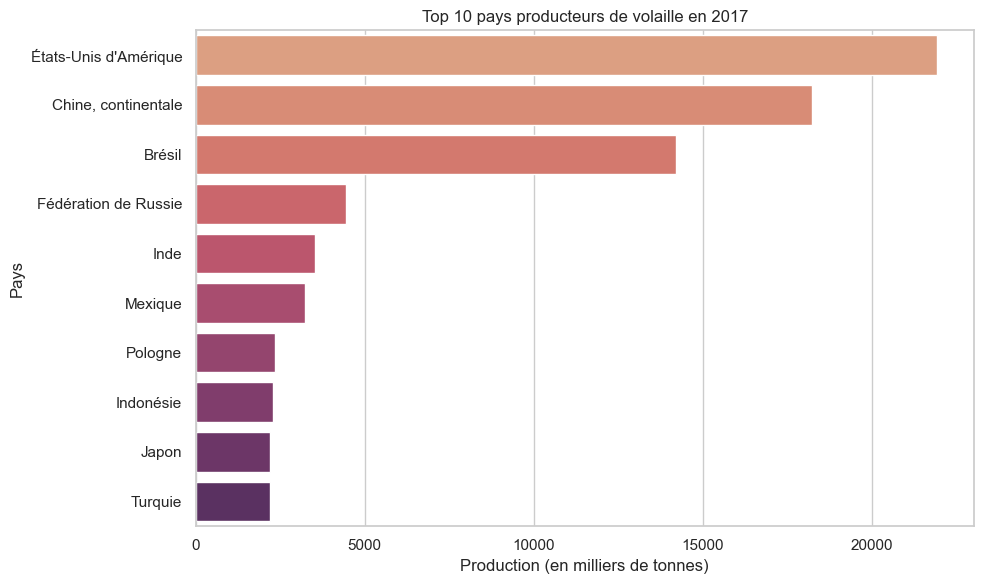

In [20]:
# Barplot pour visualiser la production des 10 premiers pays
plt.figure(figsize=(10, 6))
sns.barplot(data=top10_volaille, x='Valeur', y='Zone', palette='flare')
plt.title("Top 10 pays producteurs de volaille en 2017")
plt.xlabel("Production (en milliers de tonnes)")
plt.ylabel("Pays")
plt.tight_layout()
plt.show()

In [21]:
# Total de la production mondiale de volaille
total_volaille = dispoalimentaire_df['Valeur'].sum()

# Part de chaque pays du top 10
top10_volaille['Part (%)'] = (top10_volaille['Valeur'] / total_volaille) * 100
top10_volaille[['Zone', 'Valeur', 'Part (%)']]

,Zone,Valeur,Part (%)
56144,États-Unis d'Amérique,21914.0,17.987064
35872,"Chine, continentale",18236.0,14.968153
25062,Brésil,14201.0,11.656215
58243,Fédération de Russie,4444.0,3.647646
76625,Inde,3545.0,2.909745
108971,Mexique,3249.0,2.666787
131270,Pologne,2351.0,1.929706
77697,Indonésie,2301.0,1.888666
86119,Japon,2215.0,1.818077
168284,Turquie,2192.0,1.799199


#### 🐔 Analyse de la production de volaille (2017)

Dans cette section, nous avons exploré la base FAO 2017 pour identifier les principaux pays producteurs de volaille.

Le produit pertinent identifié était **"Viande de Volailles"**, et nous nous sommes concentrés sur l’élément **"Production"**, exprimé en **milliers de tonnes**.

Voici les principaux résultats :

- Les **États-Unis**, la **Chine** et le **Brésil** sont les trois premiers producteurs mondiaux de viande de volaille.
- Ces trois pays représentent à eux seuls **plus de 44 %** de la production mondiale.
- Les sept autres pays du top 10 (Russie, Inde, Mexique, Pologne, Indonésie, Japon, Turquie) complètent un ensemble de régions à très forte capacité de production.

Ces données pourront être utilisées pour :
- Identifier des pays concurrents dominants.
- Comprendre quels marchés sont peut-être déjà saturés ou très compétitifs.
- Croiser ces résultats avec les données de consommation ou d’importation de volaille pour repérer des **marchés sous-exploités**.

Nous pouvons désormais passer à l’analyse PESTEL pour sélectionner des variables supplémentaires utiles à l’étude de marché.

In [22]:
dispoalimentaire_df.head()

,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole
651,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5511,Production,2734,Viande de Volailles,2017,2017,Milliers de tonnes,28.0,S,Données standardisées
1704,FBS,Nouveaux Bilans Alimentaire,202,Afrique du Sud,5511,Production,2734,Viande de Volailles,2017,2017,Milliers de tonnes,1667.0,S,Données standardisées
2713,FBS,Nouveaux Bilans Alimentaire,3,Albanie,5511,Production,2734,Viande de Volailles,2017,2017,Milliers de tonnes,13.0,S,Données standardisées
3772,FBS,Nouveaux Bilans Alimentaire,4,Algérie,5511,Production,2734,Viande de Volailles,2017,2017,Milliers de tonnes,275.0,S,Données standardisées
4873,FBS,Nouveaux Bilans Alimentaire,79,Allemagne,5511,Production,2734,Viande de Volailles,2017,2017,Milliers de tonnes,1514.0,S,Données standardisées


In [23]:
# Afficher les valeurs uniques des colonnes cibles
colonnes_cibles = ['Élément', 'Code Produit', 'Produit', 'Unité', 'Symbole', 'Description du Symbole']

# Affichage des valeurs uniques dans chaque colonne
for col in colonnes_cibles:
    print(f"\n🔍 Valeurs uniques dans la colonne '{col}':")
    print(dispoalimentaire_df[col].unique())


🔍 Valeurs uniques dans la colonne 'Élément':
['Production']

🔍 Valeurs uniques dans la colonne 'Code Produit':
[2734]

🔍 Valeurs uniques dans la colonne 'Produit':
['Viande de Volailles']

🔍 Valeurs uniques dans la colonne 'Unité':
['Milliers de tonnes']

🔍 Valeurs uniques dans la colonne 'Symbole':
['S']

🔍 Valeurs uniques dans la colonne 'Description du Symbole':
['Données standardisées']


In [24]:
# Renommer les colonnes pour plus de clarté
dispoalimentaire_df.rename(columns={
    'Valeur': 'Valeur(dispoalimentaire)',
    'Unité': 'Unité(dispoalimentaire)'
}, inplace=True)

In [25]:
# Liste des colonnes à supprimer
colonnes_a_supprimer = [
    'Code Domaine', 'Domaine', 'Code zone', 'Code Élément', 'Élément',
    'Code Produit', 'Produit', 'Code année', 'Symbole', 'Description du Symbole'
]

# Suppression
dispoalimentaire_df.drop(columns=colonnes_a_supprimer, inplace=True)

# Vérification 
dispoalimentaire_df.head()

,Zone,Année,Unité(dispoalimentaire),Valeur(dispoalimentaire)
651,Afghanistan,2017,Milliers de tonnes,28.0
1704,Afrique du Sud,2017,Milliers de tonnes,1667.0
2713,Albanie,2017,Milliers de tonnes,13.0
3772,Algérie,2017,Milliers de tonnes,275.0
4873,Allemagne,2017,Milliers de tonnes,1514.0


In [26]:
# Vérifier les valeurs min et max de la colonne 'Valeur(dispoalimentaire)'
min_val = dispoalimentaire_df['Valeur(dispoalimentaire)'].min()
max_val = dispoalimentaire_df['Valeur(dispoalimentaire)'].max()

print(f"Valeur minimale : {min_val}")
print(f"Valeur maximale : {max_val}")

Valeur minimale : 0.0
Valeur maximale : 21914.0


## 5. Synthèse des données disponibles

Jusqu’à présent, deux bases principales issues de la FAO ont été analysées :

#### 1. Population (2000–2018)
- Données disponibles pour **236 pays ou zones** sur une période de **19 années**. (Seulle l'année 2017 est conservée)
- Les **10 pays les plus peuplés** représentent à eux seuls **plus de 50 %** de la population mondiale, avec la Chine, l’Inde et les États-Unis en tête.

#### 2. Données alimentaires (2017)
- Base large couvrant **plusieurs milliers de combinaisons pays/produit/élément**.
- Focalisation sur l’élément **"Production"** pour le produit **"Viande de Volailles"**.
- Les **États-Unis, la Chine et le Brésil** sont les plus gros producteurs de volaille.

Ces deux bases permettent déjà de comprendre :
- Où se trouvent les plus grandes populations → **potentiel de consommation élevé**.
- Où se concentre la production → **évaluation de la concurrence / autosuffisance**.

Cependant, elles ne suffisent pas à évaluer la **faisabilité globale** d’une stratégie d’exportation.

## 6. Premiers constats et ouverture PESTEL

#### 🔍 Premiers constats

- Les données actuelles permettent de cibler des pays avec **forte population** et/ou **production locale élevée**.
- Mais elles ne nous disent rien sur :
  - Le **pouvoir d’achat**, les habitudes de consommation, ou la demande spécifique en volaille.
  - Les **barrières réglementaires ou sanitaires**.
  - L’**ouverture économique** ou la stabilité politique.
  - Les **coûts logistiques** ou les infrastructures.
- Pour aller plus loin, nous allons utiliser une **analyse PESTEL** pour élargir notre cadre de réflexion et identifier de **nouvelles variables à intégrer**.

## 7. Sélection de variables PESTEL

#### 🎯 Objectif de cette section

L’objectif est d’élargir l’analyse actuelle à des facteurs externes pouvant influencer la faisabilité d’un projet d’exportation de viande de volaille par la France.

Pour cela, nous utilisons le cadre d’analyse **PESTEL** afin d’identifier des **nouvelles variables macro-environnementales** à intégrer à l’analyse.

In [27]:
pestel_data = {
    "Facteur": ["Politique", "Économique", "Économique", "Socioculturel", "Socioculturel", 
                "Technologique", "Environnemental", "Socioculturel"],
    "Variable proposée": ["Indice de stabilité politique", "PIB par habitant (USD)", 
                          "Inflation annuelle (%)", "Consommation de viande par habitant (kg/an)",
                          "Niveau d'urbanisation (% population urbaine)", "Accès à l’électricité (% population)",
                          "Disponibilité d’eau douce par habitant (m³/an)", 
                          "Sous-Alimentation"],
    "Pertinence": ["Risque d’instabilité", "Pouvoir d’achat", "Capacité de consommation", 
                   "Potentiel de marché pour la volaille", "Influence l’accès, la distribution et les habitudes alimentaires", 
                   "Infrastructure pour conservation", "Disponibilité pour élevage", 
                   " Indique la sécurité alimentaire, la demande potentielle pour des produits riches en protéines comme la volaille"],
    "Source": ["Banque mondiale (WGI)", "Banque mondiale", "Banque mondiale", "FAO", 
               "Banque mondiale", "Banque mondiale", "FAO / Aquastat", "FAO"]
}

df_pestel = pd.DataFrame(pestel_data)
df_pestel

,Facteur,Variable proposée,Pertinence,Source
0,Politique,Indice de stabilité politique,Risque d’instabilité,Banque mondiale (WGI)
1,Économique,PIB par habitant (USD),Pouvoir d’achat,Banque mondiale
2,Économique,Inflation annuelle (%),Capacité de consommation,Banque mondiale
3,Socioculturel,Consommation de viande par habitant (kg/an),Potentiel de marché pour la volaille,FAO
4,Socioculturel,Niveau d'urbanisation (% population urbaine),"Influence l’accès, la distribution et les habi...",Banque mondiale
5,Technologique,Accès à l’électricité (% population),Infrastructure pour conservation,Banque mondiale
6,Environnemental,Disponibilité d’eau douce par habitant (m³/an),Disponibilité pour élevage,FAO / Aquastat
7,Socioculturel,Sous-Alimentation,"Indique la sécurité alimentaire, la demande p...",FAO


#### ✅ Sélection finale de 8 variables à collecter

Après avoir considéré les différents facteurs du cadre PESTEL, les 8 variables suivantes ont été retenues pour compléter l’analyse :

1. Stabilité politique
2. PIB/habitant
3. Inflation
4. Consommation de viande par habitant
5. Niveau d'urbanisation
6. Accès à l’électricité
7. Disponibilité en eau douce
8. Sous-Alimentation

Ces variables ont été choisies pour leur **pertinence directe** dans l’analyse de la **faisabilité économique, logistique, culturelle et réglementaire** d’une stratégie d’exportation.

#### 🔄 Étapes suivantes

Les données pour ces variables seront recherchées et téléchargées depuis des sources ouvertes telles que :

- [Banque mondiale – Open Data](https://data.worldbank.org/)
- [FAO – FAOSTAT](https://www.fao.org/faostat/)
- [WTO – Data portal](https://data.wto.org/)

Elles seront ensuite nettoyées et jointes aux bases existantes pour permettre une **analyse multivariée complète (ACP, clustering)**.

# Partie 2 : Préparation et nettoyage des données issues de sources ouvertes

#### Choix méthodologique : filtrer les données sur l'année 2017

Afin de garantir la cohérence et la qualité des données utilisées pour notre analyse, j'ai fait le choix de ne conserver que les données relatives à l’année **2017**.

##### Contexte

L’un des fichiers fournis en début de projet ne contient des informations que pour l’année **2017**, tandis que d’autres sources (issues d’API comme la Banque mondiale ou la FAO) couvrent une période plus large, allant généralement de **1960 à 2024**. Si nous conservions l’ensemble des années, cela engendrerait une base déséquilibrée avec :
- Un très grand nombre de lignes contenant des valeurs manquantes,
- Des difficultés de fusion entre jeux de données hétérogènes,
- Un risque de dilution des informations lors de l’analyse multivariée (ACP, clustering).

##### Justification du choix de l’année 2017

J'ai choisi de concentrer notre analyse sur **2017** pour plusieurs raisons :
- C’est **l’année la plus récente commune** à l’ensemble des jeux de données,
- Cela garantit **l’homogénéité temporelle** entre les indicateurs,
- Cela permet de **maximiser la couverture des pays** et **minimiser les valeurs manquantes**,
- L’objectif du projet étant de **comparer les pays à un instant donné** (et non de faire une analyse temporelle), ce choix est cohérent avec la méthodologie attendue (ACP, clustering).

##### Conséquence

Chaque pays est désormais représenté par une seule ligne dans notre base finale, avec ses valeurs pour l’ensemble des variables retenues en **2017**. Cette approche simplifie la fusion des différentes sources de données et garantit une meilleure robustesse analytique pour les étapes suivantes.


#### 1. Préparation des données sur la Stabilité Politique (World Bank)

In [28]:
# Chargement des fichiers CSV dans des DataFrames

StabilitePolitique_df = pd.read_csv("StabilitePolitique.csv", sep=";", encoding="latin1", na_values="..")

# Affichage d'un aperçu de chaque jeu de données

print("✅ Customers.csv :")
display(StabilitePolitique_df.head())

✅ Customers.csv :


,codeindyr,code,countryname,year,indicator,estimate,stddev,nsource,pctrank,pctranklower,pctrankupper
0,AFGcc1996,AFG,Afghanistan,1996,cc,"-1,29","0,34",2.0,"4,3","0,0","27,4"
1,ALBcc1996,ALB,Albania,1996,cc,"-0,89","0,32",3.0,"19,4","2,7","43,0"
2,DZAcc1996,DZA,Algeria,1996,cc,"-0,57","0,26",4.0,"33,3","16,7","52,7"
3,ASMcc1996,ASM,American Samoa,1996,cc,NaN,NaN,NaN,NaN,NaN,NaN
4,ADOcc1996,ADO,Andorra,1996,cc,"1,32","0,48",1.0,"87,1","72,0","96,8"


In [29]:
# Aperçu général du fichier

print("📊 Informations générales :")
StabilitePolitique_df.info()

📊 Informations générales :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32100 entries, 0 to 32099
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   codeindyr     32100 non-null  object 
 1   code          32100 non-null  object 
 2   countryname   32100 non-null  object 
 3   year          32100 non-null  int64  
 4   indicator     32100 non-null  object 
 5   estimate      30974 non-null  object 
 6   stddev        30974 non-null  object 
 7   nsource       30974 non-null  float64
 8   pctrank       30974 non-null  object 
 9   pctranklower  30974 non-null  object 
 10  pctrankupper  30974 non-null  object 
dtypes: float64(1), int64(1), object(9)
memory usage: 2.7+ MB


In [30]:
# Colonnes à nettoyer

cols_to_convert = ["estimate", "stddev", "pctrank", "pctranklower", "pctrankupper"]

# Remplacement des virgules par des points

for col in cols_to_convert:
    StabilitePolitique_df[col] = StabilitePolitique_df[col].replace("…", pd.NA)  # remplace les "…" par NaN
    StabilitePolitique_df[col] = StabilitePolitique_df[col].str.replace(",", ".", regex=False)

# Conversion en float

StabilitePolitique_df[cols_to_convert] = StabilitePolitique_df[cols_to_convert].astype(float)

Le jeu de données contient plusieurs colonnes dont la valeur ajoutée analytique est limitée dans le cadre de notre étude comparative des pays. Nous avons donc décidé de supprimer les colonnes suivantes :

- `codeindyr` : identifiant composite redondant (code pays + indicateur + année).
- `stddev` : écart-type de l'estimation, pertinent pour une analyse fine de la précision, mais pas essentiel ici.
- `nsource` : nombre de sources ayant contribué à l’estimation, information contextuelle secondaire.
- `pctranklower` & `pctrankupper` : bornes inférieure et supérieure du centile, qui ne seront pas utilisées dans notre analyse principale.

Cette épuration vise à **simplifier le dataset**, tout en conservant les variables réellement utiles pour l’analyse.

In [31]:
# Suppression des colonnes non nécessaires

cols_to_drop = ["codeindyr", "stddev", "nsource", "pctranklower", "pctrankupper"]
StabilitePolitique_df.drop(columns=cols_to_drop, inplace=True)

In [32]:
# Filtrer sur l'année 2017
StabilitePolitique_df = StabilitePolitique_df[StabilitePolitique_df["year"] == 2017]

# Supprimer la colonne "year"
StabilitePolitique_df = StabilitePolitique_df.drop(columns=["year"])

# Vérification
StabilitePolitique_df.head()

,code,countryname,indicator,estimate,pctrank
23112,AFG,Afghanistan,cc,-1.53,3.8
23113,ALB,Albania,cc,-0.48,40.5
23114,DZA,Algeria,cc,-0.60,31.9
23115,ASM,American Samoa,cc,1.76,93.8
23116,ADO,Andorra,cc,1.17,86.2


Les indicateurs du jeu de données sont codés en abréviations peu explicites. Voici la correspondance entre les codes et les libellés complets :

| Code | Libellé complet                                                   |
|------|-------------------------------------------------------------------|
| `va` | Voice and Accountability                                          |
| `pv` | Political Stability and Absence of Violence/Terrorism            |
| `ge` | Government Effectiveness                                          |
| `rq` | Regulatory Quality                                                |
| `rl` | Rule of Law                                                       |
| `cc` | Control of Corruption                                             |

Nous allons remplacer ces abréviations par leurs libellés complets pour améliorer la lisibilité et faciliter l’analyse.

In [33]:
# Dictionnaire de correspondance des indicateurs

indicator_labels = {
    "va": "Voice and Accountability",
    "pv": "Political Stability and Absence of Violence/Terrorism",
    "ge": "Government Effectiveness",
    "rq": "Regulatory Quality",
    "rl": "Rule of Law",
    "cc": "Control of Corruption"
}

# Remplacement dans la colonne "indicator"

StabilitePolitique_df["indicator"] = StabilitePolitique_df["indicator"].map(indicator_labels)

J'ai décidé de **conserver l’ensemble des six indicateurs de gouvernance** proposés par la Banque Mondiale, car ils couvrent ensemble un spectre large et complémentaire de la qualité des institutions et du climat politico-économique :

- **Voice and Accountability** : Liberté d’expression, droits civiques et liberté de la presse.
- **Political Stability and Absence of Violence/Terrorism** : Mesure de la stabilité politique et de l'absence de violences ou de menaces terroristes.
- **Government Effectiveness** : Qualité des services publics et de la mise en œuvre des politiques.
- **Regulatory Quality** : Capacité du gouvernement à formuler et mettre en œuvre des politiques et réglementations favorables au secteur privé.
- **Rule of Law** : Confiance dans les règles juridiques, respect des contrats, sécurité des biens.
- **Control of Corruption** : Niveau de perception de la corruption dans les secteurs public et privé.

👉 Ces six dimensions sont complémentaires et fondamentales pour caractériser le niveau de gouvernance d’un pays. Nous les conserverons donc **intégralement** pour les étapes suivantes de notre analyse (ACP, clustering…).

In [34]:
# Vérification

StabilitePolitique_df.dtypes
display(StabilitePolitique_df.head())

,code,countryname,indicator,estimate,pctrank
23112,AFG,Afghanistan,Control of Corruption,-1.53,3.8
23113,ALB,Albania,Control of Corruption,-0.48,40.5
23114,DZA,Algeria,Control of Corruption,-0.60,31.9
23115,ASM,American Samoa,Control of Corruption,1.76,93.8
23116,ADO,Andorra,Control of Corruption,1.17,86.2


Le jeu de données contient six indicateurs de gouvernance issus des Worldwide Governance Indicators (WGI), produits par la Banque mondiale.

Il pourrait être tentant de créer une note synthétique unique par pays et par année, en agrégeant ces dimensions.
Cependant, ce choix n'est pas retenu, pour les raisons suivantes :
 - Perte d'information : chaque indicateur mesure un aspect distinct de la gouvernance.
 - Agrégation arbitraire : toute combinaison pondérée impliquerait un choix méthodologique discutable sans base externe solide.
 - Manque de transparence : une variable "gouvernance globale" serait difficilement interprétable et non traçable.

Alternative recommandée :

En cas de besoin de synthèse, on pourra avoir recours à une Analyse en Composantes Principales (ACP) ou à une analyse de clusters pour regrouper ou réduire l'information tout en respectant la structure des données.

In [35]:
# Vérification des valeurs manquantes

print("🕳️ Valeurs manquantes par colonne :")
print(StabilitePolitique_df.isnull().sum())

🕳️ Valeurs manquantes par colonne :
code            0
countryname     0
indicator       0
estimate       25
pctrank        25
dtype: int64


In [36]:
# Afficher les lignes où 'estimate' ou 'pctrank' sont manquantes

missing_rows = StabilitePolitique_df[StabilitePolitique_df[['estimate', 'pctrank']].isnull().any(axis=1)]
print(f"Lignes avec valeurs manquantes : {missing_rows.shape[0]}")
missing_rows.head(10)

Lignes avec valeurs manquantes : 25


,code,countryname,indicator,estimate,pctrank
23157,COK,Cook Islands,Control of Corruption,NaN,NaN
23250,ANT,Netherlands Antilles (former),Control of Corruption,NaN,NaN
23255,NIU,Niue,Control of Corruption,NaN,NaN
23371,COK,Cook Islands,Government Effectiveness,NaN,NaN
23464,ANT,Netherlands Antilles (former),Government Effectiveness,NaN,NaN
23469,NIU,Niue,Government Effectiveness,NaN,NaN
23585,COK,Cook Islands,Political Stability and Absence of Violence/Te...,NaN,NaN
23678,ANT,Netherlands Antilles (former),Political Stability and Absence of Violence/Te...,NaN,NaN
23683,NIU,Niue,Political Stability and Absence of Violence/Te...,NaN,NaN
23799,COK,Cook Islands,Rule of Law,NaN,NaN


In [37]:
# Compter combien de lignes manquantes par pays

missing_by_country = missing_rows['countryname'].value_counts()
missing_by_country.head(10)

countryname
Cook Islands                     6
Netherlands Antilles (former)    6
Niue                             6
American Samoa                   1
Anguilla                         1
Bermuda                          1
Guam                             1
Martinique                       1
Réunion                          1
Virgin Islands (U.S.)            1
Name: count, dtype: int64

In [38]:
# Voir tous les pays pour lesquels estimate ET pctrank sont systématiquement manquants

fully_missing_countries = StabilitePolitique_df.groupby('countryname')[['estimate', 'pctrank']].apply(lambda df: df.isnull().all().all())
fully_missing_countries = fully_missing_countries[fully_missing_countries]
fully_missing_countries.index.tolist()

['Cook Islands', 'Netherlands Antilles (former)', 'Niue']

**Interprétation des résultats**

Il reste 25 lignes avec valeurs manquantes dans estimate et pctrank.

Ces valeurs manquantes concernent 9 pays au total, mais 3 pays en particulier concentrent 18 des 25 lignes :
 - Cook Islands → 6 lignes
 - Netherlands Antilles (former) → 6 lignes
 - Niue → 6 lignes

Ces 3 pays n’ont aucune donnée du tout pour les indicateurs de stabilité politique. Ce sont donc des observations intégralement vides (dans les deux colonnes numériques).

Les 7 lignes restantes sont réparties sur des pays comme Réunion, Guam, Martinique, etc., et il s’agit d’observations partielles (ils ont des données pour certains indicateurs, mais pas tous).

**Supprimer les pays avec données entièrement manquantes**

Ces pays sont petits, territoriaux ou non souverains.

Ils ne sont pas pertinents pour ton analyse stratégique d’exportation internationale à grande échelle.

À supprimer : Cook Islands, Netherlands Antilles (former), Niue.

**Garder les autres pays partiellement renseignés**

Pour les autres, seules 1 ou 2 lignes sont manquantes, mais les autres indicateurs sont présents.

Dans ce cas, il est préférable de conserver ces pays avec données partielles :
 - Cela permet de maintenir une couverture géographique large.
 - Ces données seront encore utiles dans une ACP avec valeurs manquantes gérées via moyenne/imputation (ex : SimpleImputer).

In [39]:
# Liste des pays à exclure
pays_exclure = ['Cook Islands', 'Netherlands Antilles (former)', 'Niue']

# Suppression des lignes concernées
StabilitePolitique_df = StabilitePolitique_df[~StabilitePolitique_df['countryname'].isin(pays_exclure)]

In [40]:
# Pivot de la table pour avoir une colonne par indicateur (estimation + rang)
pivot_df = StabilitePolitique_df.pivot_table(
    index='countryname',
    columns='indicator',
    values=['estimate', 'pctrank']
)

# Aplatir l’index des colonnes pour avoir des noms clairs
pivot_df.columns = [f"{val}_{col}" for val, col in pivot_df.columns]
pivot_df.reset_index(inplace=True)

# Récupérer les codes pays associés (en évitant les doublons)
codes = StabilitePolitique_df[['countryname', 'code']].drop_duplicates(subset='countryname')

# Fusionner pour réintégrer les codes pays
pivot_df = pivot_df.merge(codes, on='countryname', how='left')

# Réorganiser les colonnes : code en premier
cols = ['code', 'countryname'] + [col for col in pivot_df.columns if col not in ['code', 'countryname']]
pivot_df = pivot_df[cols]

# Écraser le DataFrame original si tu veux le garder sous le même nom
StabilitePolitique_df = pivot_df.copy()

# Vérification
StabilitePolitique_df.head()

,code,countryname,estimate_Control of Corruption,estimate_Government Effectiveness,estimate_Political Stability and Absence of Violence/Terrorism,estimate_Regulatory Quality,estimate_Rule of Law,estimate_Voice and Accountability,pctrank_Control of Corruption,pctrank_Government Effectiveness,pctrank_Political Stability and Absence of Violence/Terrorism,pctrank_Regulatory Quality,pctrank_Rule of Law,pctrank_Voice and Accountability
0,AFG,Afghanistan,-1.53,-1.39,-2.79,-1.36,-1.58,-0.99,3.8,7.1,0.5,7.1,5.2,22.2
1,ALB,Albania,-0.48,0.10,0.37,0.22,-0.41,0.20,40.5,57.6,59.5,61.9,38.6,54.2
2,DZA,Algeria,-0.60,-0.54,-0.92,-1.28,-0.93,-0.90,31.9,31.4,15.7,9.0,18.1,23.2
3,ASM,American Samoa,1.76,0.51,1.18,-0.27,1.30,NaN,93.8,70.5,91.9,41.4,86.7,NaN
4,ADO,Andorra,1.17,1.88,1.39,1.20,1.54,1.16,86.2,98.1,97.1,85.7,90.5,86.2


On peut calculer la moyenne des 6 indicateurs de gouvernance (Voice & Accountability, Political Stability, Government Effectiveness, Regulatory Quality, Rule of Law, Control of Corruption) pour créer un indice global de stabilité institutionnelle.

**Intérêt** : donne une vision agrégée de la gouvernance, plutôt que 6 indicateurs séparés.

Nous avons choisi la moyenne arithmétique des six indicateurs de gouvernance comme méthodologie d’agrégation. Ce choix se justifie par l’homogénéité des échelles (–2.5 à +2.5) et par la volonté de donner un poids égal à chaque dimension institutionnelle, toutes considérées comme importantes pour évaluer la stabilité d’un marché. La moyenne présente également l’avantage d’être simple à interpréter et transparente. D’autres méthodes comme la médiane ou l’analyse factorielle auraient pu être envisagées, mais elles auraient complexifié l’analyse sans apporter une valeur ajoutée significative dans le cadre de ce projet.

In [41]:
# Calcul de l'indice moyen de stabilité politique
StabilitePolitique_df["Indice_Global_Stabilite"] = StabilitePolitique_df[
    ["estimate_Control of Corruption",
     "estimate_Government Effectiveness",
     "estimate_Political Stability and Absence of Violence/Terrorism",
     "estimate_Regulatory Quality",
     "estimate_Rule of Law",
     "estimate_Voice and Accountability"]
].mean(axis=1)

# Vérification rapide
StabilitePolitique_df[["countryname", "Indice_Global_Stabilite"]].head(10)


,countryname,Indice_Global_Stabilite
0,Afghanistan,-1.606667e+00
1,Albania,4.625929e-18
2,Algeria,-8.616667e-01
3,American Samoa,8.960000e-01
4,Andorra,1.390000e+00
5,Angola,-9.966667e-01
6,Anguilla,7.980000e-01
7,Antigua and Barbuda,3.583333e-01
8,Argentina,1.333333e-02
9,Armenia,-3.433333e-01


Dans le cadre de ce projet, nous avons créé un indice synthétique de stabilité politique en faisant la moyenne des six indicateurs de gouvernance de la Banque mondiale (allant de –2.5 à +2.5). Cette démarche relève du feature engineering, car elle consiste à transformer plusieurs variables de base en une nouvelle variable agrégée, plus simple à interpréter.

Toutefois, cet indice n’a pas été conservé dans la base finale. En effet, la moyenne repose sur une hypothèse forte d’importance égale entre toutes les dimensions institutionnelles (ex. corruption, stabilité politique, voix citoyenne), ce qui peut masquer des disparités importantes entre les sous-composantes. De plus, dans une analyse stratégique, il est souvent plus pertinent de garder une lecture détaillée des différentes dimensions institutionnelles plutôt que de les résumer en un seul chiffre.

Cet exemple reste néanmoins utile pour illustrer la mise en œuvre de feature engineering et montre comment on peut enrichir temporairement la base de données pour explorer des perspectives alternatives d’analyse.

In [42]:
StabilitePolitique_df = StabilitePolitique_df.drop(columns=["Indice_Global_Stabilite"])

#### 2. Préparation des données sur le PIB (World Bank)

In [43]:
# Chargement des fichiers CSV dans des DataFrames

PIB_df = pd.read_csv("PIB.csv", sep=";", encoding="latin1")

# Affichage d'un aperçu de chaque jeu de données

print("✅ PIB.csv :")
display(PIB_df.head())

✅ PIB.csv :


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Aruba,ABW,PIB par habitant ($ US courants),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,"27458,22533","27441,52966","28440,05196","30082,12764","31096,20507","22855,93232","27200,06108","30559,53353","33984,79062",NaN
1,NaN,AFE,PIB par habitant ($ US courants),NY.GDP.PCAP.CD,"186,1324317","186,947182","197,4081053","225,4470066","209,005786","226,883067",...,"1479,564123","1329,777824","1520,171298","1538,924188","1493,780445","1344,080962","1522,590088","1628,024526","1659,51529",NaN
2,Afghanistan,AFG,PIB par habitant ($ US courants),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,"565,5697304","522,0822156","525,4697709","491,3372214","496,6025043","510,7870634","356,4962141","357,2611528","415,7074171",NaN
3,NaN,AFW,PIB par habitant ($ US courants),NY.GDP.PCAP.CD,"121,9383531","127,4526294","133,8254524","139,0067137","148,5477359","155,5638366",...,"1845,767804","1616,843198","1560,162999","1703,896392","1783,654365","1664,249176","1747,840549","1777,235012","1568,72431",NaN
4,Angola,AGO,PIB par habitant ($ US courants),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,"3213,902611","1807,952941","2437,259712","2538,591391","2189,855714","1449,922867","1925,874661","2929,694455","2308,159767",NaN


In [44]:
# Filtrage de l'année 2017

cols_to_drop = ["1960", "1961", "1962", "1963", "1964", "1965", "1966", "1967", "1968", "1969", "1970", "1971", "1972", "1973", "1974", "1975", "1976", "1977", "1978", "1979", "1980", "1981", "1982", "1983", "1984", "1985", "1986", "1987", "1988", "1989", "1990", "1991", "1992", "1993", "1994", "1995", "1996", "1997", "1998", "1999", "2000", "2001", "2002", "2003", "2004", "2005", "2006", "2007", "2008", "2009", "2010", "2011", "2012", "2013", "2014", "2015", "2016", "2018", "2019", "2020", "2021", "2022", "2023", "2024"]
PIB_df.drop(columns=cols_to_drop, inplace=True)

In [45]:
# Aperçu général du fichier

print("📊 Informations générales :")
PIB_df.info()

📊 Informations générales :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Country Name    264 non-null    object
 1   Country Code    266 non-null    object
 2   Indicator Name  266 non-null    object
 3   Indicator Code  266 non-null    object
 4   2017            258 non-null    object
dtypes: object(5)
memory usage: 10.5+ KB


In [46]:
# Vérification des valeurs manquantes

print("🕳️ Valeurs manquantes par colonne :")
print(PIB_df.isnull().sum())

🕳️ Valeurs manquantes par colonne :
Country Name      2
Country Code      0
Indicator Name    0
Indicator Code    0
2017              8
dtype: int64


Structure du fichier :
266 lignes correspondant à des séries temporelles par pays ou entité.

Colonnes principales :
 - Country Name et Country Code : info géographique.
 - Indicator Name et Indicator Code : ici, tous sur le PIB.
 - Années de 2017 : valeurs annuelles du PIB.

Valeurs manquantes :
On a quelques valeurs manquantes en 2017 (8).

Mais surtout :

2 valeurs manquantes dans Country Name 👉 à résoudre en priorité.

Country Code est bien rempli : on peut t’en servir pour retrouver et compléter les noms manquants.

In [47]:
# Filtrer les lignes avec Country Name manquant

PIB_df[PIB_df["Country Name"].isna()]

,Country Name,Country Code,Indicator Name,Indicator Code,2017
1,NaN,AFE,PIB par habitant ($ US courants),NY.GDP.PCAP.CD,"1520,171298"
3,NaN,AFW,PIB par habitant ($ US courants),NY.GDP.PCAP.CD,"1560,162999"


On peut rechercher manuellement les noms correspondants à partir des codes ISO (ex : https://www.iban.com/country-codes).

Donc ici : 
- AFE = Africa Eastern and Southern
- AFW = Africa Western and Central

Ce sont des agrégats régionaux, pas des pays. On les retrouve souvent dans les bases de la Banque mondiale, et ils représentent des sous-régions africaines selon leur découpage. Puisque notre analyse ne porte que sur les pays et pas sur les régions, on peut supprimer ces lignes.

In [48]:
# Suppression des lignes

PIB_df = PIB_df[~PIB_df["Country Code"].isin(["AFE", "AFW"])]

In [49]:
# Nettoyage des valeurs de l'année 2017 : suppression des espaces, conversion virgule -> point, conversion en float
PIB_df['2017'] = (
    PIB_df['2017']
    .astype(str)
    .str.replace(',', '.', regex=False)
    .str.replace(' ', '', regex=False)
    .replace('nan', None)
    .astype(float)
)

In [50]:
# Les colonnes sont renommées pour plus de lisbilité

PIB_df.rename(columns={'2017': 'Valeur(PIB)'}, inplace=True)
PIB_df.rename(columns={'Indicator Name': 'Unité(PIB)'}, inplace=True)

Le fichier `PIB_df` contient deux colonnes liées à l’identification de l’indicateur :  
- `Indicator Name` : nom explicite de l’indicateur (ex. "GDP (constant 2015 US$)"),
- `Indicator Code` : code abrégé utilisé par la Banque Mondiale (ex. "NY.GDP.MKTP.KD").

➡️ Par souci de simplification et de clarté, la colonne Indicator Code est supprimées.

In [51]:
# Suppression de la colonne

PIB_df.drop(columns=["Indicator Code"], inplace=True)

In [52]:
# Vérification
PIB_df.head()

,Country Name,Country Code,Unité(PIB),Valeur(PIB)
0,Aruba,ABW,PIB par habitant ($ US courants),28440.051960
2,Afghanistan,AFG,PIB par habitant ($ US courants),525.469771
4,Angola,AGO,PIB par habitant ($ US courants),2437.259712
5,Albanie,ALB,PIB par habitant ($ US courants),4531.032207
6,Andorre,AND,PIB par habitant ($ US courants),40672.994330


In [53]:
# Vérifier les valeurs min et max de la colonne 'Valeur(PIB)'
min_val = PIB_df['Valeur(PIB)'].min()
max_val = PIB_df['Valeur(PIB)'].max()

print(f"Valeur minimale : {min_val}")
print(f"Valeur maximale : {max_val}")

Valeur minimale : 236.6944726
Valeur maximale : 170663.3752


Il est possible de créer une classification qui permet permet une lecture rapide et qualitative des niveaux de richesse des pays.
On utilisera les seuils suivants : 
 - Faible revenu : < 1 135 $
 - Revenu intermédiaire bas : 1 136 – 4 465 $
 - Revenu intermédiaire haut : 4 466 – 13 845 $
 - Haut revenu : > 13 845 $

In [54]:
# Création d'une colonne "Categorie_Revenu" basée sur les seuils BM 2024
def categoriser_pib(valeur):
    if pd.isna(valeur):
        return None
    elif valeur < 1136:
        return "Faible revenu"
    elif valeur < 4466:
        return "Revenu intermédiaire bas"
    elif valeur < 13846:
        return "Revenu intermédiaire haut"
    else:
        return "Haut revenu"

PIB_df["Categorie_Revenu"] = PIB_df["Valeur(PIB)"].apply(categoriser_pib)

# Vérification
PIB_df[["Country Name", "Valeur(PIB)", "Categorie_Revenu"]].head(10)


,Country Name,Valeur(PIB),Categorie_Revenu
0,Aruba,28440.051960,Haut revenu
2,Afghanistan,525.469771,Faible revenu
4,Angola,2437.259712,Revenu intermédiaire bas
5,Albanie,4531.032207,Revenu intermédiaire haut
6,Andorre,40672.994330,Haut revenu
7,Le monde arabe,6005.390129,Revenu intermédiaire haut
8,Émirats arabes unis,42340.591710,Haut revenu
9,Argentine,14532.500930,Haut revenu
10,Arménie,3869.053739,Revenu intermédiaire bas
11,Samoa américaines,11863.683950,Revenu intermédiaire haut


**Pourquoi on ne garde pas** : l’information est directement dérivable du PIB/habitant qui est déjà une variable quantitative beaucoup plus précise. Garder la catégorie ferait perdre en granularité sans apporter de vraie valeur ajoutée.

Mais cela peut servir d'emple de feature engineering

In [55]:
PIB_df = PIB_df.drop(columns=["Categorie_Revenu"])

#### 3. Préparation des données sur l'inflation (World Bank) 

In [56]:
# Chargement des fichiers CSV dans des DataFrames

Inflation_df = pd.read_csv("Inflation.csv", sep=";", encoding="latin1")

# Affichage d'un aperçu de chaque jeu de données

print("✅ Inflation.csv :")
display(Inflation_df.head())

✅ Inflation.csv :


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Aruba,ABW,"Inflation, prix à la consommation (% annuel)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,"0,474763597","-0,931195987","-1,028281788","3,626041414","4,257462043",NaN,NaN,NaN,NaN,NaN
1,NaN,AFE,"Inflation, prix à la consommation (% annuel)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,"5,24587835","6,596504907","6,399343416","4,720804742","4,644967173","5,405162079","7,240977656","10,77375122","7,126974821",NaN
2,Afghanistan,AFG,"Inflation, prix à la consommation (% annuel)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,"-0,661709165","4,383891955","4,975951506","0,626149149","2,302372515","5,601887915","5,133203408","13,71210237","-4,644708708","-6,601185641"
3,NaN,AFW,"Inflation, prix à la consommation (% annuel)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,"2,130817381","1,487415508","1,725486024","1,784049948","1,983092285","2,490377839","3,74570045","7,949251435","5,221168013",NaN
4,Angola,AGO,"Inflation, prix à la consommation (% annuel)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,"9,355972155","30,69441508","29,8444799","19,62893797","17,08095414","22,27153925","25,75429488","21,35529013","13,64410178","28,24049489"


In [57]:
# Filtrage de l'année 2017

cols_to_drop = ["1960", "1961", "1962", "1963", "1964", "1965", "1966", "1967", "1968", "1969", "1970", "1971", "1972", "1973", "1974", "1975", "1976", "1977", "1978", "1979", "1980", "1981", "1982", "1983", "1984", "1985", "1986", "1987", "1988", "1989", "1990", "1991", "1992", "1993", "1994", "1995", "1996", "1997", "1998", "1999", "2000", "2001", "2002", "2003", "2004", "2005", "2006", "2007", "2008", "2009", "2010", "2011", "2012", "2013", "2014", "2015", "2016", "2018", "2019", "2020", "2021", "2022", "2023", "2024"]
Inflation_df.drop(columns=cols_to_drop, inplace=True)

In [58]:
# Aperçu général du fichier

print("📊 Informations générales :")
Inflation_df.info()

📊 Informations générales :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Country Name    264 non-null    object
 1   Country Code    266 non-null    object
 2   Indicator Name  266 non-null    object
 3   Indicator Code  266 non-null    object
 4   2017            231 non-null    object
dtypes: object(5)
memory usage: 10.5+ KB


In [59]:
# Vérification des valeurs manquantes

print("🕳️ Valeurs manquantes par colonne :")
print(Inflation_df.isnull().sum())

🕳️ Valeurs manquantes par colonne :
Country Name       2
Country Code       0
Indicator Name     0
Indicator Code     0
2017              35
dtype: int64


Structure : 
Format identique au fichier PIB : colonnes d’années, lignes par pays.

Valeurs manquantes : 
35 en 2017

Cela veut dire que l’inflation est un peu moins bien couverte que le PIB dans la base — ce n’est pas anormal, certaines sources sont moins fiables sur cet indicateur.

Colonnes Country Name manquantes : 
2 valeurs manquantes comme dans le fichier PIB. Très probable que ce soient encore AFE et AFW.

In [60]:
# Affichage des lignes où le nom de pays est manquant
Inflation_df[Inflation_df["Country Name"].isna()][["Country Code", "Indicator Name"]]

,Country Code,Indicator Name
1,AFE,"Inflation, prix à la consommation (% annuel)"
3,AFW,"Inflation, prix à la consommation (% annuel)"


In [61]:
# Suppression des lignes

Inflation_df = Inflation_df[~Inflation_df["Country Code"].isin(["AFE", "AFW"])]

In [62]:
# Nettoyage des valeurs de l'année 2017 : suppression des espaces, conversion virgule -> point, conversion en float
Inflation_df['2017'] = (
    Inflation_df['2017']
    .astype(str)
    .str.replace(',', '.', regex=False)
    .str.replace(' ', '', regex=False)
    .replace('nan', None)
    .astype(float)
)

In [63]:
# Suppression de la colonne

Inflation_df.drop(columns=["Indicator Code"], inplace=True)

In [64]:
# Les colonnes sont renommées pour plus de lisbilité

Inflation_df.rename(columns={'2017': 'Valeur(inflation)'}, inplace=True)
Inflation_df.rename(columns={'Indicator Name': 'Unité(inflation)'}, inplace=True)

In [65]:
# Vérification
Inflation_df.head()

,Country Name,Country Code,Unité(inflation),Valeur(inflation)
0,Aruba,ABW,"Inflation, prix à la consommation (% annuel)",-1.028282
2,Afghanistan,AFG,"Inflation, prix à la consommation (% annuel)",4.975952
4,Angola,AGO,"Inflation, prix à la consommation (% annuel)",29.844480
5,Albanie,ALB,"Inflation, prix à la consommation (% annuel)",2.060598
6,Andorre,AND,"Inflation, prix à la consommation (% annuel)",NaN


In [66]:
# Vérifier les valeurs min et max de la colonne 'Valeur(inflation)'
min_val = Inflation_df['Valeur(inflation)'].min()
max_val = Inflation_df['Valeur(inflation)'].max()

print(f"Valeur minimale : {min_val}")
print(f"Valeur maximale : {max_val}")

Valeur minimale : -1.53709963
Valeur maximale : 187.8516303


#### 4. Préparation des données sur la Consommation de Viande (Kaggle - OECD-FAO)

In [67]:
# Chargement des fichiers CSV dans des DataFrames

MeatConsumption_df = pd.read_csv("meat_consumption.csv", sep=",", encoding="latin1")

# Affichage d'un aperçu de chaque jeu de données

print("✅ meat_consumption.csv :")
display(MeatConsumption_df.head())

✅ meat_consumption.csv :


,ï»¿LOCATION,SUBJECT,MEASURE,TIME,Value
0,AUS,BEEF,KG_CAP,1990,0.000004
1,AUS,BEEF,KG_CAP,1991,27.808401
2,AUS,BEEF,KG_CAP,1992,26.278166
3,AUS,BEEF,KG_CAP,1993,26.244478
4,AUS,BEEF,KG_CAP,1994,25.541244


In [68]:
# Aperçu général du fichier

print("📊 Informations générales :")
MeatConsumption_df.info()

📊 Informations générales :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12140 entries, 0 to 12139
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   ï»¿LOCATION  12140 non-null  object 
 1   SUBJECT      12140 non-null  object 
 2   MEASURE      12140 non-null  object 
 3   TIME         12140 non-null  int64  
 4   Value        12140 non-null  float64
dtypes: float64(1), int64(1), object(3)
memory usage: 474.3+ KB


In [69]:
# Filtrer sur l'année 2017
MeatConsumption_df = MeatConsumption_df[MeatConsumption_df["TIME"] == 2017]

# Supprimer la colonne "TIME"
MeatConsumption_df = MeatConsumption_df.drop(columns=["TIME"])

# Vérification
MeatConsumption_df.head()

,ï»¿LOCATION,SUBJECT,MEASURE,Value
27,AUS,BEEF,KG_CAP,18.715060
66,AUS,PIG,KG_CAP,22.009624
105,AUS,POULTRY,KG_CAP,43.565125
144,AUS,SHEEP,KG_CAP,7.774058
183,CAN,BEEF,KG_CAP,18.073332


In [70]:
# Vérification des valeurs manquantes

print("🕳️ Valeurs manquantes par colonne :")
print(MeatConsumption_df.isnull().sum())

🕳️ Valeurs manquantes par colonne :
ï»¿LOCATION    0
SUBJECT        0
MEASURE        0
Value          0
dtype: int64


In [71]:
# Renommer les colonnes 

MeatConsumption_df = MeatConsumption_df.rename(columns={
    "ï»¿LOCATION": "Country Code",
    "Value": "Valeur(consoVolaille)", 
    "MEASURE": "Unité(consoVolaille)"
})

In [72]:
# Voir les valeurs unique de SUBJECT

MeatConsumption_df["SUBJECT"].unique()

array(['BEEF', 'PIG', 'POULTRY', 'SHEEP'], dtype=object)

In [73]:
# Filtrer les lignes qui correspondent à la volaille

MeatConsumption_df = MeatConsumption_df[MeatConsumption_df["SUBJECT"] == "POULTRY"]

In [74]:
# Suppression de la colonne SUBJECT

MeatConsumption_df = MeatConsumption_df.drop(columns=["SUBJECT"])

In [75]:
# Aperçu des premières lignes
print("📋 Aperçu des données transformées :")
display(MeatConsumption_df.head())

# Types de données
print("\n📦 Types de données :")
print(MeatConsumption_df.dtypes)

# Dimensions et colonnes
print("\n🔍 Dimensions et colonnes :")
print(f"Lignes : {MeatConsumption_df.shape[0]}, Colonnes : {MeatConsumption_df.shape[1]}")
print("Colonnes :", MeatConsumption_df.columns.tolist())

# Valeurs manquantes
print("\n🕳️ Valeurs manquantes par colonne :")
print(MeatConsumption_df.isna().sum())


📋 Aperçu des données transformées :


,Country Code,Unité(consoVolaille),Valeur(consoVolaille)
105,AUS,KG_CAP,43.565125
261,CAN,KG_CAP,33.554069
417,JPN,KG_CAP,17.002984
573,KOR,KG_CAP,17.195695
729,MEX,KG_CAP,28.469731



📦 Types de données :
Country Code              object
Unité(consoVolaille)      object
Valeur(consoVolaille)    float64
dtype: object

🔍 Dimensions et colonnes :
Lignes : 78, Colonnes : 3
Colonnes : ['Country Code', 'Unité(consoVolaille)', 'Valeur(consoVolaille)']

🕳️ Valeurs manquantes par colonne :
Country Code             0
Unité(consoVolaille)     0
Valeur(consoVolaille)    0
dtype: int64


In [76]:
# On vérifie les colonnes qui créent les doublons

dupes = MeatConsumption_df.duplicated(subset=["Country Code"], keep=False)
MeatConsumption_df[dupes].sort_values(by=["Country Code"]).head(10)

,Country Code,Unité(consoVolaille),Valeur(consoVolaille)
7799,ARG,THND_TONNE,1914.399748
1353,ARG,KG_CAP,38.053584
105,AUS,KG_CAP,43.565125
10412,AUS,THND_TONNE,1210.445172
1509,BRA,KG_CAP,40.621666
8111,BRA,THND_TONNE,9660.952775
10997,BRICS,THND_TONNE,38733.091090
5537,BRICS,KG_CAP,10.790895
261,CAN,KG_CAP,33.554069
8969,CAN,THND_TONNE,1396.466930


On a donc des doublons qui sont dû à 2 différentes unitées :
 - KG_CAP = Consommation moyenne par habitant
 - THND_TONNE = Consommation totale du pays

On va garder KG_CAP puisque plus pertinent dans notre analyse

In [77]:
# Filtrer uniquement sur l'unité "KG_CAP"

MeatConsumption_df = MeatConsumption_df[MeatConsumption_df["Unité(consoVolaille)"] == "KG_CAP"].copy()

In [78]:
# Vérification

print("🔁 Nombre de doublons (par pays + année) :")
print(MeatConsumption_df.duplicated(subset=["Country Code"]).sum())

display(MeatConsumption_df.head())

🔁 Nombre de doublons (par pays + année) :
0


,Country Code,Unité(consoVolaille),Valeur(consoVolaille)
105,AUS,KG_CAP,43.565125
261,CAN,KG_CAP,33.554069
417,JPN,KG_CAP,17.002984
573,KOR,KG_CAP,17.195695
729,MEX,KG_CAP,28.469731


In [79]:
# Vérifier les valeurs min et max de la colonne 'Valeur(consoVolaille)'
min_val = MeatConsumption_df['Valeur(consoVolaille)'].min()
max_val = MeatConsumption_df['Valeur(consoVolaille)'].max()

print(f"Valeur minimale : {min_val}")
print(f"Valeur maximale : {max_val}")

Valeur minimale : 0.114874826
Valeur maximale : 65.77975596


#### 5. Préparation des données sur le niveau d'urbanisation (World Bank)

In [80]:
# Chargement des fichiers CSV dans des DataFrames

PopUrbaine_df = pd.read_csv("PopUrbaine.csv", sep=";", encoding="latin1")

# Affichage d'un aperçu de chaque jeu de données

print("✅ PopUrbaine.csv :")
display(PopUrbaine_df.head())

✅ PopUrbaine.csv :


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Aruba,ABW,Population urbaine (% du total),SP.URB.TOTL.IN.ZS,"50,776","50,761","50,746","50,73","50,715","50,7",...,"43,108","43,192","43,293","43,411","43,546","43,697","43,866","44,052","44,254",NaN
1,NaN,AFE,Population urbaine (% du total),SP.URB.TOTL.IN.ZS,"14,57667646","14,82517525","15,08380153","15,36304464","15,65538331","15,95591209",...,"34,44728076","34,91954438","35,39628946","35,89339793","36,38427229","36,88403448","37,39363253","37,90901202","38,42489805",NaN
2,Afghanistan,AFG,Population urbaine (% du total),SP.URB.TOTL.IN.ZS,"8,401","8,684","8,976","9,276","9,586","9,904",...,"24,803","25,02","25,25","25,495","25,754","26,026","26,314","26,616","26,933",NaN
3,NaN,AFW,Population urbaine (% du total),SP.URB.TOTL.IN.ZS,"14,71000567","15,0944452","15,48793216","15,9006819","16,33131914","16,77979297",...,"44,84909949","45,47385023","46,09413656","46,70975262","47,32261736","47,93102096","48,53197106","49,12980799","49,71118412",NaN
4,Angola,AGO,Population urbaine (% du total),SP.URB.TOTL.IN.ZS,"10,435","10,798","11,204","11,624","12,058","12,504",...,"63,446","64,149","64,839","65,514","66,177","66,825","67,46","68,081","68,688",NaN


In [81]:
# Filtrage de l'année 2017

cols_to_drop = ["1960", "1961", "1962", "1963", "1964", "1965", "1966", "1967", "1968", "1969", "1970", "1971", "1972", "1973", "1974", "1975", "1976", "1977", "1978", "1979", "1980", "1981", "1982", "1983", "1984", "1985", "1986", "1987", "1988", "1989", "1990", "1991", "1992", "1993", "1994", "1995", "1996", "1997", "1998", "1999", "2000", "2001", "2002", "2003", "2004", "2005", "2006", "2007", "2008", "2009", "2010", "2011", "2012", "2013", "2014", "2015", "2016", "2018", "2019", "2020", "2021", "2022", "2023", "2024"]
PopUrbaine_df.drop(columns=cols_to_drop, inplace=True)

In [82]:
# Aperçu général du fichier

print("📊 Informations générales :")
PopUrbaine_df.info()

📊 Informations générales :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Country Name    264 non-null    object
 1   Country Code    266 non-null    object
 2   Indicator Name  266 non-null    object
 3   Indicator Code  266 non-null    object
 4   2017            263 non-null    object
dtypes: object(5)
memory usage: 10.5+ KB


In [83]:
# Vérification des valeurs manquantes

print("🕳️ Valeurs manquantes par colonne :")
print(PopUrbaine_df.isnull().sum())

🕳️ Valeurs manquantes par colonne :
Country Name      2
Country Code      0
Indicator Name    0
Indicator Code    0
2017              3
dtype: int64


Structure :
266 lignes (donc probablement un pays par ligne, avec quelques entités additionnelles).

Données manquantes :
 - 2 valeurs manquantes dans Country Name → probablement des lignes sans pays (comme des agrégats régionaux ou erreurs).
 - 3 valeurs manquantes pour l'année de 2017 → très léger taux de données manquantes 

Cela suggère qu’un nettoyage similaire aux fichiers précédents sera nécessaire : suppression des virgules éventuelles, conversion en float, etc.

In [84]:
# Afficher les lignes avec 'Country Name' manquant

missing_countries = PopUrbaine_df[PopUrbaine_df["Country Name"].isna()]
print(missing_countries[["Country Name", "Country Code", "Indicator Name"]])

  Country Name Country Code                   Indicator Name
1          NaN          AFE  Population urbaine (% du total)
3          NaN          AFW  Population urbaine (% du total)


In [85]:
# Suppression des lignes

PopUrbaine_df = PopUrbaine_df[~PopUrbaine_df["Country Code"].isin(["AFE", "AFW"])]

In [86]:
# Nettoyage des valeurs de l'année 2017 : suppression des espaces, conversion virgule -> point, conversion en float
PopUrbaine_df['2017'] = (
    PopUrbaine_df['2017']
    .astype(str)
    .str.replace(',', '.', regex=False)
    .str.replace(' ', '', regex=False)
    .replace('nan', None)
    .astype(float)
)

In [87]:
# Suppression de la colonne

PopUrbaine_df.drop(columns=["Indicator Code"], inplace=True)

In [88]:
# Les colonnes sont renommées pour plus de lisbilité

PopUrbaine_df.rename(columns={'2017': 'Valeur(PopUrbaine)'}, inplace=True)
PopUrbaine_df.rename(columns={'Indicator Name': 'Unité(PopUrbaine)'}, inplace=True)

In [89]:
# Vérification
PopUrbaine_df.head()

,Country Name,Country Code,Unité(PopUrbaine),Valeur(PopUrbaine)
0,Aruba,ABW,Population urbaine (% du total),43.293
2,Afghanistan,AFG,Population urbaine (% du total),25.250
4,Angola,AGO,Population urbaine (% du total),64.839
5,Albanie,ALB,Population urbaine (% du total),59.383
6,Andorre,AND,Population urbaine (% du total),88.150


In [90]:
# Vérifier les valeurs min et max de la colonne 'Valeur(PopUrbaine)'
min_val = PopUrbaine_df['Valeur(PopUrbaine)'].min()
max_val = PopUrbaine_df['Valeur(PopUrbaine)'].max()

print(f"Valeur minimale : {min_val}")
print(f"Valeur maximale : {max_val}")

Valeur minimale : 12.706
Valeur maximale : 100.0


#### 6. Préparation des données sur l'Accès à l'Electricité (World Bank)

In [91]:
# Chargement des fichiers CSV dans des DataFrames

AccesElectricite_df = pd.read_csv("AccesElectricite.csv", sep=";", encoding="latin1")

# Affichage d'un aperçu de chaque jeu de données

print("✅ AccesElectricite.csv :")
display(AccesElectricite_df.head())

✅ AccesElectricite.csv :


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Aruba,ABW,Accès à lélectricité (% de la population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,100,100,100,100,100,100,100,"99,9",100,NaN
1,NaN,AFE,Accès à lélectricité (% de la population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,"33,92227566","38,85959766","40,22374417","43,03507335","44,39086053","46,28237095","48,12721104","48,80125796","50,66833048",NaN
2,Afghanistan,AFG,Accès à lélectricité (% de la population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,"71,5","97,7","97,7","93,4","97,7","97,7","97,7","85,3","85,3",NaN
3,NaN,AFW,Accès à lélectricité (% de la population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,"46,86241825","51,04512719","48,90072805","51,33582935","51,29157691","51,85604285","54,36859871","55,68668297","57,06926658",NaN
4,Angola,AGO,Accès à lélectricité (% de la population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,42,"41,8","42,9","45,3","45,6",47,"48,2","48,5","51,1",NaN


In [92]:
# Filtrage de l'année 2017

cols_to_drop = ["1960", "1961", "1962", "1963", "1964", "1965", "1966", "1967", "1968", "1969", "1970", "1971", "1972", "1973", "1974", "1975", "1976", "1977", "1978", "1979", "1980", "1981", "1982", "1983", "1984", "1985", "1986", "1987", "1988", "1989", "1990", "1991", "1992", "1993", "1994", "1995", "1996", "1997", "1998", "1999", "2000", "2001", "2002", "2003", "2004", "2005", "2006", "2007", "2008", "2009", "2010", "2011", "2012", "2013", "2014", "2015", "2016", "2018", "2019", "2020", "2021", "2022", "2023", "2024"]
AccesElectricite_df.drop(columns=cols_to_drop, inplace=True)

In [93]:
# Aperçu général du fichier

print("📊 Informations générales :")
PopUrbaine_df.info()

📊 Informations générales :
<class 'pandas.core.frame.DataFrame'>
Index: 264 entries, 0 to 265
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Country Name        264 non-null    object 
 1   Country Code        264 non-null    object 
 2   Unité(PopUrbaine)   264 non-null    object 
 3   Valeur(PopUrbaine)  261 non-null    float64
dtypes: float64(1), object(3)
memory usage: 10.3+ KB


In [94]:
# Vérification des valeurs manquantes

print("🕳️ Valeurs manquantes par colonne :")
print(AccesElectricite_df.isnull().sum())

🕳️ Valeurs manquantes par colonne :
Country Name      2
Country Code      0
Indicator Name    0
Indicator Code    0
2017              3
dtype: int64


Structure :
265 lignes (donc probablement un pays par ligne, avec quelques entités additionnelles).

Données manquantes :
 - 2 valeurs manquantes dans Country Name → probablement des lignes sans pays (comme des agrégats régionaux ou erreurs).
 - 3 valeurs manquantes pour l'année de 2017 → très léger taux de données manquantes 

Cela suggère qu’un nettoyage similaire aux fichiers précédents sera nécessaire : suppression des virgules éventuelles, conversion en float, etc.

In [95]:
# Afficher les lignes avec 'Country Name' manquant

missing_countries = AccesElectricite_df[AccesElectricite_df["Country Name"].isna()]
print(missing_countries[["Country Name", "Country Code", "Indicator Name"]])

  Country Name Country Code                              Indicator Name
1          NaN          AFE  Accès à lélectricité (% de la population)
3          NaN          AFW  Accès à lélectricité (% de la population)


In [96]:
# Suppression des lignes

AccesElectricite_df = AccesElectricite_df[~AccesElectricite_df["Country Code"].isin(["AFE", "AFW"])]

In [97]:
# Nettoyage des valeurs de l'année 2017 : suppression des espaces, conversion virgule -> point, conversion en float
AccesElectricite_df['2017'] = (
    AccesElectricite_df['2017']
    .astype(str)
    .str.replace(',', '.', regex=False)
    .str.replace(' ', '', regex=False)
    .replace('nan', None)
    .astype(float)
)

In [98]:
# Suppression de la colonne

AccesElectricite_df.drop(columns=["Indicator Code"], inplace=True)

In [99]:
# Les colonnes sont renommées pour plus de lisbilité

AccesElectricite_df.rename(columns={'2017': 'Valeur(AccesElectricite)'}, inplace=True)
AccesElectricite_df.rename(columns={'Indicator Name': 'Unité(AccesElectricite)'}, inplace=True)

In [100]:
# Vérification
AccesElectricite_df.head()

,Country Name,Country Code,Unité(AccesElectricite),Valeur(AccesElectricite)
0,Aruba,ABW,Accès à lélectricité (% de la population),100.0
2,Afghanistan,AFG,Accès à lélectricité (% de la population),97.7
4,Angola,AGO,Accès à lélectricité (% de la population),42.9
5,Albanie,ALB,Accès à lélectricité (% de la population),99.9
6,Andorre,AND,Accès à lélectricité (% de la population),100.0


In [101]:
# Vérifier les valeurs min et max de la colonne 'Valeur(dispoalimentaire)'
min_val = AccesElectricite_df['Valeur(AccesElectricite)'].min()
max_val = AccesElectricite_df['Valeur(AccesElectricite)'].max()

print(f"Valeur minimale : {min_val}")
print(f"Valeur maximale : {max_val}")

Valeur minimale : 4.2
Valeur maximale : 100.0


#### 7. Préparation des données sur la Disponibilité en Eau Douce (World Bank)

In [102]:
# Chargement des fichiers CSV dans des DataFrames

EauDouce_df = pd.read_csv("EauDouce.csv", sep=";", encoding="latin1")

# Affichage d'un aperçu de chaque jeu de données

print("✅ EauDouce.csv :")
display(EauDouce_df.head())

✅ EauDouce.csv :


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Aruba,ABW,Renewable internal freshwater resources per ca...,ER.H2O.INTR.PC,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,Renewable internal freshwater resources per ca...,ER.H2O.INTR.PC,NaN,"18494,09126","17999,33524","17514,78777","17034,61351","16561,43049",...,"3270,549216","3185,306452","3102,243905","3018,561579","2937,506056","2859,260825","2784,493962",NaN,NaN,NaN
2,Afghanistan,AFG,Renewable internal freshwater resources per ca...,ER.H2O.INTR.PC,NaN,NaN,"5013,607452","4909,163811","4804,205448","4698,083142",...,"1393,660703","1358,765661","1321,13777","1283,236261","1245,505317","1206,839831","1178,737859",NaN,NaN,NaN
3,Africa Western and Central,AFW,Renewable internal freshwater resources per ca...,ER.H2O.INTR.PC,NaN,"19040,25","18638,69764","18238,59205","17844,41994","17453,28733",...,"4540,33383","4420,582217","4305,995933","4198,268797","4097,068709","4000,342618","3906,890239",NaN,NaN,NaN
4,Angola,AGO,Renewable internal freshwater resources per ca...,ER.H2O.INTR.PC,NaN,"27916,19032","27641,28338","27365,24466","27085,45663","26801,9756",...,"5256,092824","5071,43354","4895,015317","4728,864333","4571,339333","4424,364473","4285,82652",NaN,NaN,NaN


In [103]:
# Filtrage de l'année 2017

cols_to_drop = ["1960", "1961", "1962", "1963", "1964", "1965", "1966", "1967", "1968", "1969", "1970", "1971", "1972", "1973", "1974", "1975", "1976", "1977", "1978", "1979", "1980", "1981", "1982", "1983", "1984", "1985", "1986", "1987", "1988", "1989", "1990", "1991", "1992", "1993", "1994", "1995", "1996", "1997", "1998", "1999", "2000", "2001", "2002", "2003", "2004", "2005", "2006", "2007", "2008", "2009", "2010", "2011", "2012", "2013", "2014", "2015", "2016", "2018", "2019", "2020", "2021", "2022", "2023", "2024"]
EauDouce_df.drop(columns=cols_to_drop, inplace=True)

In [104]:
# Aperçu général du fichier

print("📊 Informations générales :")
EauDouce_df.info()

📊 Informations générales :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Country Name    266 non-null    object
 1   Country Code    266 non-null    object
 2   Indicator Name  266 non-null    object
 3   Indicator Code  266 non-null    object
 4   2017            231 non-null    object
dtypes: object(5)
memory usage: 10.5+ KB


In [105]:
# Vérification des valeurs manquantes

print("🕳️ Valeurs manquantes par colonne :")
print(EauDouce_df.isnull().sum())

🕳️ Valeurs manquantes par colonne :
Country Name       0
Country Code       0
Indicator Name     0
Indicator Code     0
2017              35
dtype: int64


Structure :
265 lignes (donc probablement un pays par ligne, avec quelques entités additionnelles).

Données manquantes :
 - 35 valeurs manquantes pour l'année de 2017 → très léger taux de données manquantes 

Cela suggère qu’un nettoyage similaire aux fichiers précédents sera nécessaire : suppression des virgules éventuelles, conversion en float, etc.

In [106]:
# Nettoyage des valeurs de l'année 2017 : suppression des espaces, conversion virgule -> point, conversion en float
EauDouce_df['2017'] = (
    EauDouce_df['2017']
    .astype(str)
    .str.replace(',', '.', regex=False)
    .str.replace(' ', '', regex=False)
    .replace('nan', None)
    .astype(float)
)

In [107]:
# Suppression de la colonne

EauDouce_df.drop(columns=["Indicator Code"], inplace=True)

In [108]:
# Les colonnes sont renommées pour plus de lisbilité

EauDouce_df.rename(columns={'2017': 'Valeur(EauDouce)'}, inplace=True)
EauDouce_df.rename(columns={'Indicator Name': 'Unité(EauDouce)'}, inplace=True)

In [109]:
# Vérification
EauDouce_df.head()

,Country Name,Country Code,Unité(EauDouce),Valeur(EauDouce)
0,Aruba,ABW,Renewable internal freshwater resources per ca...,NaN
1,Africa Eastern and Southern,AFE,Renewable internal freshwater resources per ca...,3102.243905
2,Afghanistan,AFG,Renewable internal freshwater resources per ca...,1321.137770
3,Africa Western and Central,AFW,Renewable internal freshwater resources per ca...,4305.995933
4,Angola,AGO,Renewable internal freshwater resources per ca...,4895.015317


In [110]:
# Vérifier les valeurs min et max de la colonne 'Valeur(dispoalimentaire)'
min_val = EauDouce_df['Valeur(EauDouce)'].min()
max_val = EauDouce_df['Valeur(EauDouce)'].max()

print(f"Valeur minimale : {min_val}")
print(f"Valeur maximale : {max_val}")

Valeur minimale : 0.0
Valeur maximale : 495049.505


Selon la classification de la FAO, les ressources renouvelables internes en eau douce par habitant sont utilisées pour mesurer la pression hydrique d’un pays. Les seuils de référence sont les suivants :
 - > 1700 m³/hab/an → situation confortable,
 - 1000 – 1700 m³/hab/an → stress hydrique,
 - < 1000 m³/hab/an → pénurie chronique d’eau.

Nous avons créé une nouvelle variable qualitative « Catégorie_EauDouce » basée sur ces seuils, afin d’intégrer un indicateur directement interprétable de la disponibilité en eau. Cette transformation est un exemple de feature engineering, car elle enrichit les données en partant d’une variable brute.

In [111]:
import pandas as pd
import numpy as np

# Fonction pour classer selon les seuils FAO
def classer_eau(val):
    if pd.isna(val):
        return np.nan
    elif val > 1700:
        return "Confortable"
    elif val >= 1000:
        return "Stress hydrique"
    else:
        return "Pénurie chronique"

# Création de la nouvelle colonne
EauDouce_df["Catégorie_EauDouce"] = EauDouce_df["Valeur(EauDouce)"].apply(classer_eau)

# Vérification rapide
EauDouce_df[["Country Name", "Valeur(EauDouce)", "Catégorie_EauDouce"]].head(10)

,Country Name,Valeur(EauDouce),Catégorie_EauDouce
0,Aruba,NaN,NaN
1,Africa Eastern and Southern,3102.243905,Confortable
2,Afghanistan,1321.137770,Stress hydrique
3,Africa Western and Central,4305.995933,Confortable
4,Angola,4895.015317,Confortable
5,Albania,9361.546040,Confortable
6,Andorra,4278.567846,Confortable
7,Arab World,263.305667,Pénurie chronique
8,United Arab Emirates,16.263292,Pénurie chronique
9,Argentina,6593.075004,Confortable


Bien que pertinente pour une première lecture, la variable « Catégorie_EauDouce » n’a pas été retenue dans notre sélection finale. En effet, la disponibilité en eau par habitant, bien que stratégique pour l’agriculture et l’élevage, ne constitue pas un critère décisif pour notre problématique centrée sur le potentiel d’exportation. Nous avons donc choisi de l’écarter afin de garder un jeu de variables plus resserré et cohérent avec nos objectifs.

In [112]:
EauDouce_df = EauDouce_df.drop(columns=["Catégorie_EauDouce"])

#### 8. Préparation des données sur l'Indice de sous nutrition (World Bank)

In [113]:
# Chargement des fichiers CSV dans des DataFrames

SousAlimentation_df = pd.read_csv("SousNutrition.csv", sep=";", encoding="latin1")

# Affichage d'un aperçu de chaque jeu de données

print("✅ SousNutrition.csv :")
display(SousAlimentation_df.head())

✅ SousNutrition.csv :


,ï»¿Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (SDG),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,SDGB,SDG Indicators,4,Afghanistan,6121,Value,SN_ITK_DEFC,2.1.1 Prevalence of undernourishment,2017,2017,%,21.4,E,Estimated value,Estimated | Food and Agriculture Organization ...
1,SDGB,SDG Indicators,8,Albania,6121,Value,SN_ITK_DEFC,2.1.1 Prevalence of undernourishment,2017,2017,%,4.3,E,Estimated value,Estimated | Food and Agriculture Organization ...
2,SDGB,SDG Indicators,12,Algeria,6121,Value,SN_ITK_DEFC,2.1.1 Prevalence of undernourishment,2017,2017,%,2.5,E,Estimated value,Estimated | Food and Agriculture Organization ...
3,SDGB,SDG Indicators,24,Angola,6121,Value,SN_ITK_DEFC,2.1.1 Prevalence of undernourishment,2017,2017,%,15.2,E,Estimated value,Estimated | Food and Agriculture Organization ...
4,SDGB,SDG Indicators,32,Argentina,6121,Value,SN_ITK_DEFC,2.1.1 Prevalence of undernourishment,2017,2017,%,3.4,E,Estimated value,Estimated | Food and Agriculture Organization ...


In [114]:
# Aperçu général du fichier

print("📊 Informations générales :")
SousAlimentation_df.info()

📊 Informations générales :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 216 entries, 0 to 215
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   ï»¿Domain Code    216 non-null    object
 1   Domain            216 non-null    object
 2   Area Code (M49)   216 non-null    int64 
 3   Area              216 non-null    object
 4   Element Code      216 non-null    int64 
 5   Element           216 non-null    object
 6   Item Code (SDG)   216 non-null    object
 7   Item              216 non-null    object
 8   Year Code         216 non-null    int64 
 9   Year              216 non-null    int64 
 10  Unit              216 non-null    object
 11  Value             215 non-null    object
 12  Flag              216 non-null    object
 13  Flag Description  216 non-null    object
 14  Note              216 non-null    object
dtypes: int64(4), object(11)
memory usage: 25.4+ KB


In [115]:
# Vérification des valeurs manquantes

print("🕳️ Valeurs manquantes par colonne :")
print(SousAlimentation_df.isnull().sum())

🕳️ Valeurs manquantes par colonne :
ï»¿Domain Code      0
Domain              0
Area Code (M49)     0
Area                0
Element Code        0
Element             0
Item Code (SDG)     0
Item                0
Year Code           0
Year                0
Unit                0
Value               1
Flag                0
Flag Description    0
Note                0
dtype: int64


Structure :
215 lignes (donc probablement un pays par ligne).

Données manquantes :
 - 1 valeurs manquantes pour l'année de 2017 → très léger taux de données manquantes 

In [116]:
# Supprimer les colonnes inutiles
colonnes_a_supprimer = [
    "ï»¿Domain Code", "Domain", "Area Code (M49)", "Element Code", "Element",
    "Item Code (SDG)", "Item", "Year Code", "Year", "Flag", "Flag Description", "Note"
]
SousAlimentation_df = SousAlimentation_df.drop(columns=colonnes_a_supprimer)

In [117]:
# Vérifier les valeurs uniques dans la colonne 'Unit'
unit_values = SousAlimentation_df["Unit"].unique()
print("Valeurs uniques dans la colonne 'Unit' :", unit_values)

# Remplacer '%' par une description plus explicite si c’est bien la seule valeur
if set(unit_values) == {"%"}:
    SousAlimentation_df["Unit"] = "Prevalence of undernourishment (%)"
else:
    print("⚠️ Attention : la colonne 'Unit' contient des valeurs inattendues :", unit_values)

Valeurs uniques dans la colonne 'Unit' : ['%']


In [118]:
# Supprimer les espaces ou caractères parasites éventuels
SousAlimentation_df["Value"] = SousAlimentation_df["Value"].str.replace(",", ".").str.strip()

# Convertir en float (ignore les erreurs si certaines valeurs sont manquantes)
SousAlimentation_df["Value"] = pd.to_numeric(SousAlimentation_df["Value"], errors="coerce")

# Vérification
print(SousAlimentation_df["Value"].dtypes)
print(SousAlimentation_df["Value"].describe())

float64
count    150.000000
mean      12.813333
std       10.426365
min        2.500000
25%        5.725000
50%        9.050000
75%       16.775000
max       58.300000
Name: Value, dtype: float64


In [119]:
# Les colonnes sont renommées pour plus de lisbilité

SousAlimentation_df.rename(columns={'Unit': 'Unité(SousAlimentation)'}, inplace=True)
SousAlimentation_df.rename(columns={'Value': 'Valeur(SousAlimentation)'}, inplace=True)

In [120]:
# Aperçu du résultat
SousAlimentation_df.head()

,Area,Unité(SousAlimentation),Valeur(SousAlimentation)
0,Afghanistan,Prevalence of undernourishment (%),21.4
1,Albania,Prevalence of undernourishment (%),4.3
2,Algeria,Prevalence of undernourishment (%),2.5
3,Angola,Prevalence of undernourishment (%),15.2
4,Argentina,Prevalence of undernourishment (%),3.4


#### 9. Fusion et nettoyage final du jeu de données global

#### 9.1 Préparation du fichier de liaison (opendatasoft)

In [121]:
# Chargement des fichiers CSV dans des DataFrames

Liaison_df = pd.read_csv("countries-codes.csv", sep=";", encoding="latin1")

# Affichage d'un aperçu de chaque jeu de données

print("✅ countries-codes.csv :")
display(Liaison_df.head())

✅ countries-codes.csv :


,ï»¿OFFICIAL LANG CODE,ISO2 CODE,ISO3 CODE,ONU CODE,IS ILOMEMBER,IS RECEIVING QUEST,LABEL EN,LABEL FR,LABEL SP,Geo Shape,geo_point_2d
0,EN,KH,KHM,116,Y,Y,Cambodia,Cambodge,Camboya,"{""coordinates"": [[[[103.804860873, 10.46320221...","12.7158741325, 104.902961879"
1,FR,CH,CHE,756,Y,Y,Switzerland,Suisse,Suiza,"{""coordinates"": [[[8.617437378, 47.757318624],...","46.7990859221, 8.21591266153"
2,EN,NG,NGA,566,Y,Y,Nigeria,NigÃ©ria,Nigeria,"{""coordinates"": [[[[7.45191491, 4.475531317], ...","9.59507580848, 8.09141781395"
3,EN,CZ,CZE,203,Y,Y,Czech Republic,RÃ©publique tchÃ¨que,RepÃºblica Checa,"{""coordinates"": [[[14.397808064, 51.013114726]...","49.7324459146, 15.3140847769"
4,EN,UZ,UZB,860,Y,Y,Uzbekistan,OuzbÃ©kistan,UzbekistÃ¡n,"{""coordinates"": [[[[71.757304321, 39.903095194...","41.7554735142, 63.1405371045"


In [122]:
# Supprimer les colonnes inutiles
colonnes_a_supprimer = [
    "ï»¿OFFICIAL LANG CODE", "ISO2 CODE", "ONU CODE", "IS ILOMEMBER", "IS RECEIVING QUEST", "LABEL SP", "Geo Shape", "geo_point_2d"
]
Liaison_df = Liaison_df.drop(columns=colonnes_a_supprimer)

In [123]:
# Aperçu général du fichier

print("📊 Informations générales :")
Liaison_df.info()

# Vérification des valeurs manquantes

print("🕳️ Valeurs manquantes par colonne :")
print(Liaison_df.isnull().sum())

📊 Informations générales :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247 entries, 0 to 246
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ISO3 CODE  247 non-null    object
 1   LABEL EN   247 non-null    object
 2   LABEL FR   247 non-null    object
dtypes: object(3)
memory usage: 5.9+ KB
🕳️ Valeurs manquantes par colonne :
ISO3 CODE    0
LABEL EN     0
LABEL FR     0
dtype: int64


In [124]:
# Vérification des doublons

print("🔎 Vérification des doublons par colonne :\n")

for col in Liaison_df.columns:
    nb_total = Liaison_df.shape[0]
    nb_uniques = Liaison_df[col].nunique()
    nb_doublons = nb_total - nb_uniques

    print(f"Colonne '{col}' → {nb_doublons} doublon(s) détecté(s) ({nb_uniques} valeurs uniques sur {nb_total})")

🔎 Vérification des doublons par colonne :

Colonne 'ISO3 CODE' → 0 doublon(s) détecté(s) (247 valeurs uniques sur 247)
Colonne 'LABEL EN' → 0 doublon(s) détecté(s) (247 valeurs uniques sur 247)
Colonne 'LABEL FR' → 1 doublon(s) détecté(s) (246 valeurs uniques sur 247)


In [125]:
# Trouver les valeurs de 'LABEL FR' qui apparaissent plus d'une fois
doublons_label_fr = Liaison_df['LABEL FR'][Liaison_df['LABEL FR'].duplicated(keep=False)]

print("🎯 Valeurs dupliquées dans 'LABEL FR' :")
print(doublons_label_fr.unique())

# Afficher toutes les lignes ayant une de ces valeurs dupliquées
Liaison_df[Liaison_df['LABEL FR'].isin(doublons_label_fr)]

🎯 Valeurs dupliquées dans 'LABEL FR' :
['Soudan, RÃ©publique du']


,ISO3 CODE,LABEL EN,LABEL FR
60,SDN,"Sudan, The Republic of","Soudan, RÃ©publique du"
148,SSD,"South Sudan, The Republic of","Soudan, RÃ©publique du"


In [126]:
# Corriger l'étiquette du Soudan du Sud uniquement
Liaison_df.loc[Liaison_df['ISO3 CODE'] == 'SSD', 'LABEL FR'] = 'Soudan du Sud, R\u00e9publique du'

In [127]:
# Vérification des problèmes d'encodage

import re

def detect_encoding_issues(series):
    # Recherche les caractères non ASCII (souvent signes de problème d'encodage)
    non_ascii = series[series.apply(lambda x: bool(re.search(r'[^\x00-\x7F]', str(x))))]
    return non_ascii.unique()

# Problèmes potentiels dans LABEL EN
print("Problèmes potentiels dans LABEL EN :")
print(detect_encoding_issues(Liaison_df['LABEL EN']))

# Problèmes potentiels dans LABEL FR
print("\nProblèmes potentiels dans LABEL FR :")
print(detect_encoding_issues(Liaison_df['LABEL FR']))

Problèmes potentiels dans LABEL EN :
['RÃ©union' 'Germany, 5 new LÃ¤nder and Berlin (East)' "CÃ´te d'Ivoire"]

Problèmes potentiels dans LABEL FR :
['NigÃ©ria' 'RÃ©publique tchÃ¨que' 'OuzbÃ©kistan' 'Guyane franÃ§aise'
 'BahreÃ¯n' 'Venezuela, RÃ©p. bolivarienne du' 'RÃ©union' 'GÃ©orgie'
 'Allemagne, RÃ©p. FÃ©d. avant le 3.10.1990' 'MontÃ©nÃ©gro'
 'Bosnie-HerzÃ©govine' 'Papouasie-Nouvelle-GuinÃ©e'
 'RÃ©publique arabe syrienne' 'JamaÃ¯que' 'GuinÃ©e-Bissau'
 "Iran, RÃ©p. islamique d'" 'Nouvelle-CalÃ©donie' 'BrunÃ©i Darussalam'
 'BrÃ©sil' 'NorvÃ¨ge' 'CorÃ©e, RÃ©p. pop. dÃ©m. de'
 'Soudan, RÃ©publique du' 'NiouÃ©'
 'Allemagne, 5 nouveaux LÃ¤nder et Berlin-Est' 'PÃ©rou'
 'Iles Vierges amÃ©ricaines' 'Malaisie: Malaisie pÃ©ninsulaire' 'SuÃ¨de'
 'Iles CaÃ¯manes' "Ethiopie (y compris l'ErythrÃ©e)"
 'Allemagne, Ancienne RÃ©p. dÃ©m. allemande' 'TaÃ¯wan, Chine'
 'Congo, RÃ©p. dÃ©m. du' 'YÃ©men' 'Iles Turques et CaÃ¯ques' 'KoweÃ¯t'
 'YÃ©men, Ancien YÃ©men dÃ©mocratique' 'GrÃ¨ce' 'Russie, FÃ©dÃ©ration

In [128]:
# Correction des erreurs d'encodage

def safe_fix_encoding(text):
    try:
        return text.encode('latin1').decode('utf-8')
    except (UnicodeEncodeError, UnicodeDecodeError):
        return text  # On retourne tel quel si encodage/décodage échoue

# Appliquer la correction aux deux colonnes
Liaison_df['LABEL EN'] = Liaison_df['LABEL EN'].apply(safe_fix_encoding)
Liaison_df['LABEL FR'] = Liaison_df['LABEL FR'].apply(safe_fix_encoding)

In [129]:
# Vérification
def detect_encoding_issues(series):
    return series[series.str.contains('Ã|Ã©|Ã¨|Ãª|Ã®|Ã«|Ã¢|Ã¤|Ã´|Ã¶|Ã¹|Ã»|Ãœ|Ã–|ÃŸ', na=False)].unique()

print("Problèmes restants dans LABEL EN :", detect_encoding_issues(Liaison_df['LABEL EN']))
print("Problèmes restants dans LABEL FR :", detect_encoding_issues(Liaison_df['LABEL FR']))

Problèmes restants dans LABEL EN : []
Problèmes restants dans LABEL FR : []


In [130]:
display(Liaison_df.head())

,ISO3 CODE,LABEL EN,LABEL FR
0,KHM,Cambodia,Cambodge
1,CHE,Switzerland,Suisse
2,NGA,Nigeria,Nigéria
3,CZE,Czech Republic,République tchèque
4,UZB,Uzbekistan,Ouzbékistan


#### 9.2 Jointures

##### 9.2.1 Jointure Liaison_df et population_df

In [131]:
corrections_zone = {
    "Antilles néerlandaises (ex)": "Antilles néerlandaises",
    "Bolivie (État plurinational de)": "Bolivie",
    "Cabo Verde": "Cap-Vert",
    "Chine - RAS de Hong-Kong": "Hong-kong, Chine",
    "Chine - RAS de Macao": "Macao, Chine",
    "Chine, Taiwan Province de": "Taïwan, Chine",
    "Chine, continentale": "Chine",
    "République populaire démocratique de Corée": "Corée, Rép. pop. dém. de",
    "République de Corée": "Corée, République de",
    "République de Moldova": "Moldova, République de",
    "République démocratique du Congo": "Congo, Rép. dém. du",
    "République démocratique populaire lao": "République dém. pop. lao",
    "Égypte": "Egypte",
    "États-Unis d'Amérique": "Etats-Unis",
    "Érythrée": "Erythrée",
    "Eswatini": "Swaziland",
    "Équateur": "Equateur",
    "Éthiopie": "Ethiopie",
    "Émirats arabes unis": "Emirats arabes unis",
    "Fédération de Russie": "Russie, Fédération de",
    "Iran (République islamique d')": "Iran, Rép. islamique d'",
    "Libye": "Jamahiriya arabe libyenne",
    "Macédoine du Nord": "Macédoine, Ex-Rép. yougoslave de",
    "Micronésie (États fédérés de)": "Micronésie",
    "Palaos": "Palau",
    "Palestine": "Rive occidentale et Bande de Gaza",
    "République-Unie de Tanzanie": "Tanzanie, République-Unie de",
    "Royaume-Uni de Grande-Bretagne et d'Irlande du Nord": "Royaume-Uni",
    "Soudan": "Soudan, République du",
    "Soudan du Sud": "Soudan du Sud, République du",
    "Tchéquie": "République tchèque",
    "Venezuela (République bolivarienne du)": "Venezuela, Rép. bolivarienne du",
    "Île de Man": "Ile de Man",
    "Îles Anglo-Normandes": "Iles Anglo-normandes",
    "Îles Caïmanes": "Iles Caïmanes",
    "Îles Cook": "Iles Cook",
    "Îles Falkland (Malvinas)": "Iles Falkland (Malvinas)",
    "Îles Féroé": "Iles Féroé",
    "Îles Mariannes du Nord": "Iles Mariannes du Nord",
    "Îles Marshall": "Iles Marshall",
    "Îles Salomon": "Iles Salomon",
    "Îles Turques-et-Caïques": "Iles Turques et Caïques",
    "Îles Vierges américaines": "Iles Vierges américaines",
    "Îles Vierges britanniques": "Iles Vierges britanniques",
    "Îles Wallis-et-Futuna": "Iles Wallis et Futuna",
}

In [132]:
# Remplacer les valeurs dans 'Zone' par leurs équivalents officiels
population_df['Zone'] = population_df['Zone'].replace(corrections_zone)

In [133]:
# Jointure complète entre population_df et Liaison_df
Jointure01_df = population_df.merge(
    Liaison_df,
    how='outer',                      # Garde toutes les lignes des deux DataFrames
    left_on='Zone',
    right_on='LABEL FR'
)

In [134]:
# Identifier les lignes sans correspondance dans l'une ou l'autre table
jointure_problemes = Jointure01_df[Jointure01_df['Zone'].isnull() | Jointure01_df['LABEL FR'].isnull()]
print(f"🔎 Lignes sans correspondance dans l'une des deux tables : {jointure_problemes.shape[0]}")

🔎 Lignes sans correspondance dans l'une des deux tables : 29


In [135]:
# Extraire toutes les lignes non appariées (celles avec des valeurs manquantes dans l'une des deux colonnes clés)
lignes_non_appariees = Jointure01_df[
    Jointure01_df['Zone'].isna() | Jointure01_df['LABEL FR'].isna()
]

# Afficher toutes ces lignes
lignes_non_appariees

,Zone,Unité(population),Valeur(population),ISO3 CODE,LABEL EN,LABEL FR
5,NaN,NaN,NaN,DE3,"Germany, 5 new Länder and Berlin (East)","Allemagne, 5 nouveaux Länder et Berlin-Est"
6,NaN,NaN,NaN,DE1,"Germany, The former German Dem. Rep.","Allemagne, Ancienne Rép. dém. allemande"
7,NaN,NaN,NaN,DE2,"Germany, Fed. Rep. of before 3.10.1990","Allemagne, Rép. Féd. avant le 3.10.1990"
29,"Bonaire, Saint-Eustache et Saba",1000 personnes,25.401,NaN,NaN,NaN
55,Curaçao,1000 personnes,161.997,NaN,NaN,NaN
69,NaN,NaN,NaN,ET1,Ethiopia (including Eritrea),Ethiopie (y compris l'Erythrée)
83,NaN,NaN,NaN,GGY,Guernsey,Guernesey
94,NaN,NaN,NaN,NFK,Norfolk Island,Ile Norfolk
119,NaN,NaN,NaN,JEY,Jersey,Jersey
125,NaN,NaN,NaN,KOS,Kosovo,Kosovo


Les valeurs présentent uniquement dans le dataset Liaison_df ne posent aucun problème puisque servent uniquement à la liaison.
Les autres correspondent à des îles, qui pour la plupart sont des territoires d'outre mer (France, Pays-Bas, etc).

On va donc voir la proportion qu'elless représentent, et supprimer ces lignes si non impactant/utiles.

In [136]:
# S'assurer que la colonne est bien numérique
Jointure01_df['Valeur(population)'] = pd.to_numeric(Jointure01_df['Valeur(population)'], errors='coerce')

# Population mondiale totale
population_totale = Jointure01_df['Valeur(population)'].sum()
print(f"Population mondiale totale (en milliers) : {population_totale:.0f}")

Population mondiale totale (en milliers) : 7548134


In [137]:
iles_a_supprimer = [
    "Bonaire, Saint-Eustache et Saba",
    "Curaçao",
    "Mayotte",
    "Micronésie",
    "Saint-Barthélemy",
    "Saint-Martin (partie française)",
    "Saint-Siège",
    "Sainte-Hélène, Ascension et Tristan da Cunha",
    "Sint Maarten (partie néerlandaise)"
]

In [138]:
population_iles = Jointure01_df[Jointure01_df['Zone'].isin(iles_a_supprimer)]['Valeur(population)'].sum()
print(f"Population totale des îles à exclure (en milliers) : {population_iles:.0f}")

# Proportion par rapport à la population mondiale
proportion = population_iles / population_totale * 100
print(f"Proportion de la population mondiale représentée par ces îles : {proportion:.4f}%")

Population totale des îles à exclure (en milliers) : 605
Proportion de la population mondiale représentée par ces îles : 0.0080%


Donc on peut supprimer.

In [139]:
# Suppression
Jointure01_df = Jointure01_df[~Jointure01_df['Zone'].isin(iles_a_supprimer)]

In [140]:
# On supprime la ligne récalcitrante
Jointure01_df = Jointure01_df[~Jointure01_df['Zone'].str.contains("Sint Maarten", na=False)]

In [141]:
# Vérification
lignes_non_appariees = Jointure01_df[
    Jointure01_df['Zone'].isna() | Jointure01_df['LABEL FR'].isna()
]

lignes_non_appariees

,Zone,Unité(population),Valeur(population),ISO3 CODE,LABEL EN,LABEL FR
5,NaN,NaN,NaN,DE3,"Germany, 5 new Länder and Berlin (East)","Allemagne, 5 nouveaux Länder et Berlin-Est"
6,NaN,NaN,NaN,DE1,"Germany, The former German Dem. Rep.","Allemagne, Ancienne Rép. dém. allemande"
7,NaN,NaN,NaN,DE2,"Germany, Fed. Rep. of before 3.10.1990","Allemagne, Rép. Féd. avant le 3.10.1990"
69,NaN,NaN,NaN,ET1,Ethiopia (including Eritrea),Ethiopie (y compris l'Erythrée)
83,NaN,NaN,NaN,GGY,Guernsey,Guernesey
94,NaN,NaN,NaN,NFK,Norfolk Island,Ile Norfolk
119,NaN,NaN,NaN,JEY,Jersey,Jersey
125,NaN,NaN,NaN,KOS,Kosovo,Kosovo
138,NaN,NaN,NaN,MY1,Malaysia: Peninsular Malaysia,Malaisie: Malaisie péninsulaire
139,NaN,NaN,NaN,MY2,Malaysia: Sabah,Malaisie: Sabah


In [142]:
display(Jointure01_df.head())

,Zone,Unité(population),Valeur(population),ISO3 CODE,LABEL EN,LABEL FR
0,Afghanistan,1000 personnes,36296.113,AFG,Afghanistan,Afghanistan
1,Afrique du Sud,1000 personnes,57009.756,ZAF,South Africa,Afrique du Sud
2,Albanie,1000 personnes,2884.169,ALB,Albania,Albanie
3,Algérie,1000 personnes,41389.189,DZA,Algeria,Algérie
4,Allemagne,1000 personnes,82658.409,DEU,Germany,Allemagne


In [143]:
# Suppression de la colonne "Zone"
if "Zone" in Jointure01_df.columns:
    Jointure01_df = Jointure01_df.drop(columns=["Zone"])

# Nombre de valeurs manquantes dans la colonne "Valeur(population)"
missing_values = Jointure01_df["Valeur(population)"].isna().sum()
print(f"Valeurs manquantes dans 'Valeur(population)' : {missing_values}")

# Vérification de doublons dans le DataFrame
duplicates = Jointure01_df.duplicated().sum()
print(f"Nombre de doublons : {duplicates}")

import re

# Détection de caractères non ASCII dans les colonnes de type string
for col in Jointure01_df.select_dtypes(include='object').columns:
    mask = Jointure01_df[col].apply(lambda x: bool(re.search(r'[^\x00-\x7F]', str(x))))
    if mask.any():
        print(f"Problèmes d'encodage détectés dans la colonne : {col}")
        print(Jointure01_df[mask][col].unique())

Valeurs manquantes dans 'Valeur(population)' : 20
Nombre de doublons : 0
Problèmes d'encodage détectés dans la colonne : LABEL EN
['Germany, 5 new Länder and Berlin (East)' "Côte d'Ivoire" 'Réunion']
Problèmes d'encodage détectés dans la colonne : LABEL FR
['Algérie' 'Allemagne, 5 nouveaux Länder et Berlin-Est'
 'Allemagne, Ancienne Rép. dém. allemande'
 'Allemagne, Rép. Féd. avant le 3.10.1990' 'Antilles néerlandaises'
 'Arménie' 'Azerbaïdjan' 'Bahreïn' 'Bosnie-Herzégovine'
 'Brunéi Darussalam' 'Brésil' 'Bélarus' 'Bénin' 'Congo, Rép. dém. du'
 'Corée, Rép. pop. dém. de' 'Corée, République de' "Côte d'Ivoire"
 'Erythrée' "Ethiopie (y compris l'Erythrée)" 'Grèce' 'Guinée'
 'Guinée équatoriale' 'Guinée-Bissau' 'Guyane française' 'Géorgie' 'Haïti'
 'Iles Caïmanes' 'Iles Féroé' 'Iles Turques et Caïques'
 'Iles Vierges américaines' 'Indonésie' "Iran, Rép. islamique d'" 'Israël'
 'Jamaïque' 'Koweït' 'Libéria' 'Macédoine, Ex-Rép. yougoslave de'
 'Malaisie: Malaisie péninsulaire' 'Moldova, Rép

Valeurs manquantes : **20** => correspond aux 20 lignes non appariées restantes

Pas de doublons

Problèmes d'encodage : Il ne s'agit pas d’erreurs d'encodage à corriger, mais simplement de la présence normale de caractères accentués ou non-ASCII dans des noms de pays en français (ou en allemand dans certains cas). **Aucune action corrective n’est donc nécessaire ici**, tant que l'encodage du fichier reste en UTF-8.

##### 9.2.2 Jointure Liaison_df et dispoalimentaire_df

In [144]:
corrections_zone = {
    "Antilles néerlandaises (ex)": "Antilles néerlandaises",
    "Bolivie (État plurinational de)": "Bolivie",
    "Cabo Verde": "Cap-Vert",
    "Chine - RAS de Hong-Kong": "Hong-kong, Chine",
    "Chine - RAS de Macao": "Macao, Chine",
    "Chine, Taiwan Province de": "Taïwan, Chine",
    "Chine, continentale": "Chine",
    "République populaire démocratique de Corée": "Corée, Rép. pop. dém. de",
    "République de Corée": "Corée, République de",
    "République de Moldova": "Moldova, République de",
    "République démocratique du Congo": "Congo, Rép. dém. du",
    "République démocratique populaire lao": "République dém. pop. lao",
    "Égypte": "Egypte",
    "États-Unis d'Amérique": "Etats-Unis",
    "Érythrée": "Erythrée",
    "Eswatini": "Swaziland",
    "Équateur": "Equateur",
    "Éthiopie": "Ethiopie",
    "Émirats arabes unis": "Emirats arabes unis",
    "Fédération de Russie": "Russie, Fédération de",
    "Iran (République islamique d')": "Iran, Rép. islamique d'",
    "Libye": "Jamahiriya arabe libyenne",
    "Macédoine du Nord": "Macédoine, Ex-Rép. yougoslave de",
    "Micronésie (États fédérés de)": "Micronésie",
    "Palaos": "Palau",
    "Palestine": "Rive occidentale et Bande de Gaza",
    "République-Unie de Tanzanie": "Tanzanie, République-Unie de",
    "Royaume-Uni de Grande-Bretagne et d'Irlande du Nord": "Royaume-Uni",
    "Soudan": "Soudan, République du",
    "Soudan du Sud": "Soudan du Sud, République du",
    "Tchéquie": "République tchèque",
    "Venezuela (République bolivarienne du)": "Venezuela, Rép. bolivarienne du",
    "Île de Man": "Ile de Man",
    "Îles Anglo-Normandes": "Iles Anglo-normandes",
    "Îles Caïmanes": "Iles Caïmanes",
    "Îles Cook": "Iles Cook",
    "Îles Falkland (Malvinas)": "Iles Falkland (Malvinas)",
    "Îles Féroé": "Iles Féroé",
    "Îles Mariannes du Nord": "Iles Mariannes du Nord",
    "Îles Marshall": "Iles Marshall",
    "Îles Salomon": "Iles Salomon",
    "Îles Turques-et-Caïques": "Iles Turques et Caïques",
    "Îles Vierges américaines": "Iles Vierges américaines",
    "Îles Vierges britanniques": "Iles Vierges britanniques",
    "Îles Wallis-et-Futuna": "Iles Wallis et Futuna",
}

# Appliquer les corrections sur la colonne 'Zone'
dispoalimentaire_df['Zone'] = dispoalimentaire_df['Zone'].replace(corrections_zone)

In [145]:
# Jointure extérieure (outer) pour conserver toutes les lignes des deux dataframes
Jointure02_df = pd.merge(
    dispoalimentaire_df,
    Jointure01_df,
    how='outer',
    left_on='Zone',
    right_on='LABEL FR'
)

# Afficher un aperçu de la nouvelle table
Jointure02_df.head()

,Zone,Année,Unité(dispoalimentaire),Valeur(dispoalimentaire),Unité(population),Valeur(population),ISO3 CODE,LABEL EN,LABEL FR
0,Afghanistan,2017.0,Milliers de tonnes,28.0,1000 personnes,36296.113,AFG,Afghanistan,Afghanistan
1,Afrique du Sud,2017.0,Milliers de tonnes,1667.0,1000 personnes,57009.756,ZAF,South Africa,Afrique du Sud
2,Albanie,2017.0,Milliers de tonnes,13.0,1000 personnes,2884.169,ALB,Albania,Albanie
3,Algérie,2017.0,Milliers de tonnes,275.0,1000 personnes,41389.189,DZA,Algeria,Algérie
4,Allemagne,2017.0,Milliers de tonnes,1514.0,1000 personnes,82658.409,DEU,Germany,Allemagne


In [146]:
# Identifier les lignes non appariées (sans correspondance dans l'une ou l'autre table)
lignes_non_appariees = Jointure02_df[
    Jointure02_df['Zone'].isna() | Jointure02_df['LABEL FR'].isna()
]

# Afficher le nombre et les premières lignes concernées
print(f"Nombre de lignes non appariées : {len(lignes_non_appariees)}")
lignes_non_appariees.head(127)

Nombre de lignes non appariées : 79


,Zone,Année,Unité(dispoalimentaire),Valeur(dispoalimentaire),Unité(population),Valeur(population),ISO3 CODE,LABEL EN,LABEL FR
5,NaN,NaN,NaN,NaN,NaN,NaN,DE3,"Germany, 5 new Länder and Berlin (East)","Allemagne, 5 nouveaux Länder et Berlin-Est"
6,NaN,NaN,NaN,NaN,NaN,NaN,DE1,"Germany, The former German Dem. Rep.","Allemagne, Ancienne Rép. dém. allemande"
7,NaN,NaN,NaN,NaN,NaN,NaN,DE2,"Germany, Fed. Rep. of before 3.10.1990","Allemagne, Rép. Féd. avant le 3.10.1990"
8,NaN,NaN,NaN,NaN,1000 personnes,77.001,AND,Andorra,Andorre
10,NaN,NaN,NaN,NaN,1000 personnes,14.584,AIA,Anguilla,Anguilla
12,NaN,NaN,NaN,NaN,1000 personnes,275.186,ANT,Netherlands Antilles,Antilles néerlandaises
16,NaN,NaN,NaN,NaN,1000 personnes,105.366,ABW,Aruba,Aruba
21,NaN,NaN,NaN,NaN,1000 personnes,1494.076,BHR,Bahrain,Bahreïn
26,NaN,NaN,NaN,NaN,1000 personnes,63.049,BMU,Bermuda,Bermudes
27,NaN,NaN,NaN,NaN,1000 personnes,745.563,BTN,Bhutan,Bhoutan


In [147]:
# Suppression de la colonne "Zone" et de la colonne "Année"
colonnes_a_supprimer = [
    "Zone", "Année"
]
Jointure02_df = Jointure02_df.drop(columns=colonnes_a_supprimer)

# Nombre de valeurs manquantes dans la colonne "Valeur(population)"
missing_values = Jointure02_df["Valeur(dispoalimentaire)"].isna().sum()
print(f"Valeurs manquantes dans 'Valeur(dispoalimentaire)' : {missing_values}")

# Vérification de doublons dans le DataFrame
duplicates = Jointure02_df.duplicated().sum()
print(f"Nombre de doublons : {duplicates}")

Valeurs manquantes dans 'Valeur(dispoalimentaire)' : 79
Nombre de doublons : 0


Valeurs manquantes : **79** => correspond aux 79 lignes non appariées restantes

Pas de doublons

##### 9.2.3 Jointure Liaison_df et StabilitePolitique_df

In [148]:
corrections_code = {
    "ADO": "AND",
    "KSV": "KOS",
    "ROM": "ROU",
    "TMP": "TLS",
    "WBG": "PSE",
    "ZAR": "COD",
}

# Appliquer les corrections sur la colonne 'Zone'
StabilitePolitique_df['code'] = StabilitePolitique_df['code'].replace(corrections_code)

In [149]:
# Jointure extérieure (outer) pour conserver toutes les lignes des deux dataframes
Jointure03_df = pd.merge(
    StabilitePolitique_df,
    Jointure02_df,
    how='outer',
    left_on='code',
    right_on='ISO3 CODE'
)

# Afficher un aperçu de la nouvelle table
Jointure03_df.head()

,code,countryname,estimate_Control of Corruption,estimate_Government Effectiveness,estimate_Political Stability and Absence of Violence/Terrorism,estimate_Regulatory Quality,estimate_Rule of Law,estimate_Voice and Accountability,pctrank_Control of Corruption,pctrank_Government Effectiveness,...,pctrank_Regulatory Quality,pctrank_Rule of Law,pctrank_Voice and Accountability,Unité(dispoalimentaire),Valeur(dispoalimentaire),Unité(population),Valeur(population),ISO3 CODE,LABEL EN,LABEL FR
0,ABW,Aruba,1.24,0.88,1.31,1.18,1.30,1.30,87.6,78.1,...,83.8,87.1,92.6,NaN,NaN,1000 personnes,105.366,ABW,Aruba,Aruba
1,AFG,Afghanistan,-1.53,-1.39,-2.79,-1.36,-1.58,-0.99,3.8,7.1,...,7.1,5.2,22.2,Milliers de tonnes,28.0,1000 personnes,36296.113,AFG,Afghanistan,Afghanistan
2,AGO,Angola,-1.45,-0.95,-0.39,-1.05,-1.04,-1.10,5.7,17.1,...,12.4,14.8,18.2,Milliers de tonnes,42.0,1000 personnes,29816.766,AGO,Angola,Angola
3,AIA,Anguilla,1.17,0.78,1.36,0.83,-0.15,NaN,86.2,75.7,...,78.1,49.5,NaN,NaN,NaN,1000 personnes,14.584,AIA,Anguilla,Anguilla
4,ALB,Albania,-0.48,0.10,0.37,0.22,-0.41,0.20,40.5,57.6,...,61.9,38.6,54.2,Milliers de tonnes,13.0,1000 personnes,2884.169,ALB,Albania,Albanie


In [150]:
# Identifier les lignes non appariées (sans correspondance dans l'une ou l'autre table)
lignes_non_appariees = Jointure03_df[
    Jointure03_df['code'].isna() | Jointure03_df['ISO3 CODE'].isna()
]

# Afficher le nombre et les premières lignes concernées
print(f"Nombre de lignes non appariées : {len(lignes_non_appariees)}")
lignes_non_appariees.head(38)

Nombre de lignes non appariées : 38


,code,countryname,estimate_Control of Corruption,estimate_Government Effectiveness,estimate_Political Stability and Absence of Violence/Terrorism,estimate_Regulatory Quality,estimate_Rule of Law,estimate_Voice and Accountability,pctrank_Control of Corruption,pctrank_Government Effectiveness,...,pctrank_Regulatory Quality,pctrank_Rule of Law,pctrank_Voice and Accountability,Unité(dispoalimentaire),Valeur(dispoalimentaire),Unité(population),Valeur(population),ISO3 CODE,LABEL EN,LABEL FR
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1000 personnes,275.186,ANT,Netherlands Antilles,Antilles néerlandaises
35,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1000 personnes,168.665,CHA,Channel Islands,Iles Anglo-normandes
43,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1000 personnes,17.507,COK,Cook Islands,Iles Cook
48,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CS1,Czechoslovakia,Tchécoslovaquie
53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DE1,"Germany, The former German Dem. Rep.","Allemagne, Ancienne Rép. dém. allemande"
54,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DE2,"Germany, Fed. Rep. of before 3.10.1990","Allemagne, Rép. Féd. avant le 3.10.1990"
55,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DE3,"Germany, 5 new Länder and Berlin (East)","Allemagne, 5 nouveaux Länder et Berlin-Est"
65,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1000 personnes,552.615,ESH,Western Sahara,Sahara occidental
68,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ET1,Ethiopia (including Eritrea),Ethiopie (y compris l'Erythrée)
72,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1000 personnes,3.068,FLK,Falkland Islands (Malvinas),Iles Falkland (Malvinas)


Puisqu'on a déjà supprimé la ligne pour la Micronésie plus, tôt, on la supprime ici aussi.

In [151]:
# On supprime la ligne 
Jointure03_df = Jointure03_df[~Jointure03_df['code'].str.contains("Micronesia", na=False)]

In [152]:
# Suppression de la colonne "code" et de la colonne "countryname"
colonnes_a_supprimer = [
    "code", "countryname"
]
Jointure03_df = Jointure03_df.drop(columns=colonnes_a_supprimer)

# Vérification de doublons dans le DataFrame
duplicates = Jointure03_df.duplicated().sum()
print(f"Nombre de doublons : {duplicates}")

Nombre de doublons : 0


ok, pas de doublons

##### 9.2.4 Jointure Liaison_df et PIB_df

In [153]:
corrections_code = {
    "XKX": "COD",
}

# Appliquer les corrections sur la colonne 'Zone'
PIB_df['Country Code'] = PIB_df['Country Code'].replace(corrections_code)

In [154]:
# Jointure extérieure (outer) pour conserver toutes les lignes des deux dataframes
Jointure04_df = pd.merge(
    PIB_df,
    Jointure03_df,
    how='outer',
    left_on='Country Code',
    right_on='ISO3 CODE'
)

# Afficher un aperçu de la nouvelle table
Jointure04_df.head()

,Country Name,Country Code,Unité(PIB),Valeur(PIB),estimate_Control of Corruption,estimate_Government Effectiveness,estimate_Political Stability and Absence of Violence/Terrorism,estimate_Regulatory Quality,estimate_Rule of Law,estimate_Voice and Accountability,...,pctrank_Regulatory Quality,pctrank_Rule of Law,pctrank_Voice and Accountability,Unité(dispoalimentaire),Valeur(dispoalimentaire),Unité(population),Valeur(population),ISO3 CODE,LABEL EN,LABEL FR
0,Aruba,ABW,PIB par habitant ($ US courants),28440.051960,1.24,0.88,1.31,1.18,1.30,1.30,...,83.8,87.1,92.6,NaN,NaN,1000 personnes,105.366,ABW,Aruba,Aruba
1,Afghanistan,AFG,PIB par habitant ($ US courants),525.469771,-1.53,-1.39,-2.79,-1.36,-1.58,-0.99,...,7.1,5.2,22.2,Milliers de tonnes,28.0,1000 personnes,36296.113,AFG,Afghanistan,Afghanistan
2,Angola,AGO,PIB par habitant ($ US courants),2437.259712,-1.45,-0.95,-0.39,-1.05,-1.04,-1.10,...,12.4,14.8,18.2,Milliers de tonnes,42.0,1000 personnes,29816.766,AGO,Angola,Angola
3,NaN,NaN,NaN,NaN,1.17,0.78,1.36,0.83,-0.15,NaN,...,78.1,49.5,NaN,NaN,NaN,1000 personnes,14.584,AIA,Anguilla,Anguilla
4,Albanie,ALB,PIB par habitant ($ US courants),4531.032207,-0.48,0.10,0.37,0.22,-0.41,0.20,...,61.9,38.6,54.2,Milliers de tonnes,13.0,1000 personnes,2884.169,ALB,Albania,Albanie


In [155]:
# Identifier les lignes non appariées (sans correspondance dans l'une ou l'autre table)
lignes_non_appariees = Jointure04_df[
    Jointure04_df['Country Code'].isna() | Jointure04_df['ISO3 CODE'].isna()
]

# Afficher le nombre et les premières lignes concernées
print(f"Nombre de lignes non appariées : {len(lignes_non_appariees)}")
lignes_non_appariees.head(89)

Nombre de lignes non appariées : 89


,Country Name,Country Code,Unité(PIB),Valeur(PIB),estimate_Control of Corruption,estimate_Government Effectiveness,estimate_Political Stability and Absence of Violence/Terrorism,estimate_Regulatory Quality,estimate_Rule of Law,estimate_Voice and Accountability,...,pctrank_Regulatory Quality,pctrank_Rule of Law,pctrank_Voice and Accountability,Unité(dispoalimentaire),Valeur(dispoalimentaire),Unité(population),Valeur(population),ISO3 CODE,LABEL EN,LABEL FR
3,NaN,NaN,NaN,NaN,1.17,0.78,1.36,0.83,-0.15,NaN,...,78.1,49.5,NaN,NaN,NaN,1000 personnes,14.584,AIA,Anguilla,Anguilla
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1000 personnes,275.186,ANT,Netherlands Antilles,Antilles néerlandaises
7,Le monde arabe,ARB,PIB par habitant ($ US courants),6005.390129,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
36,Europe centrale et les pays baltes,CEB,PIB par habitant ($ US courants),14294.447020,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
37,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1000 personnes,168.665,CHA,Channel Islands,Iles Anglo-normandes
39,Îles Anglo-Normandes,CHI,PIB par habitant ($ US courants),55806.570910,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
47,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1000 personnes,17.507,COK,Cook Islands,Iles Cook
52,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CS1,Czechoslovakia,Tchécoslovaquie
53,Petits états des Caraïbes,CSS,PIB par habitant ($ US courants),11775.390500,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
55,Curacao,CUW,PIB par habitant ($ US courants),18938.244050,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Parmis ces 89 lignes non appariées, 52 sont dues au fichier PIB_df, et parmis celles-ci : 
 - 5 correspondent à des îles déjà exclues du dataframe => on les supprime
 - 47 correspondent à des regroupements (régions du globe, revenus, continents, etc) => inutiles dans notre analyse, on les supprime

In [156]:
# Liste des lignes à exclure
lignes_exclues = ['ARB', 'CEB', 'CHI', 'CSS', 'CUW', 'EAP', 'EAR', 'EAS', 'ECA', 'ECS', 'EMU', 'EUU', 'FCS', 'FSM', 'HIC', 'HPC', 'IBD', 'IBT', 'IDA', 'IDB', 'IDX', 'INX', 'LAC', 'LCN', 'LDC', 'LIC', 'LMC', 'LMY', 'LTE', 'MAF', 'MEA', 'MIC', 'MNA', 'NAC', 'OED', 'OSS', 'PRE', 'PSS', 'PST', 'SAS', 'SSA', 'SSF', 'SST', 'SXM', 'TEA', 'TEC', 'TLA', 'TMN', 'TSA', 'TSS', 'UMC', 'WLD']

# Suppression des lignes concernées
Jointure04_df = Jointure04_df[~Jointure04_df['Country Code'].isin(lignes_exclues)]

In [157]:
# Vérification
lignes_non_appariees = Jointure04_df[
    Jointure04_df['Country Code'].isna() | Jointure04_df['ISO3 CODE'].isna()
]

print(f"Nombre de lignes non appariées : {len(lignes_non_appariees)}")
lignes_non_appariees.head(37)

Nombre de lignes non appariées : 37


,Country Name,Country Code,Unité(PIB),Valeur(PIB),estimate_Control of Corruption,estimate_Government Effectiveness,estimate_Political Stability and Absence of Violence/Terrorism,estimate_Regulatory Quality,estimate_Rule of Law,estimate_Voice and Accountability,...,pctrank_Regulatory Quality,pctrank_Rule of Law,pctrank_Voice and Accountability,Unité(dispoalimentaire),Valeur(dispoalimentaire),Unité(population),Valeur(population),ISO3 CODE,LABEL EN,LABEL FR
3,NaN,NaN,NaN,NaN,1.17,0.78,1.36,0.83,-0.15,NaN,...,78.1,49.5,NaN,NaN,NaN,1000 personnes,14.584,AIA,Anguilla,Anguilla
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1000 personnes,275.186,ANT,Netherlands Antilles,Antilles néerlandaises
37,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1000 personnes,168.665,CHA,Channel Islands,Iles Anglo-normandes
47,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1000 personnes,17.507,COK,Cook Islands,Iles Cook
52,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CS1,Czechoslovakia,Tchécoslovaquie
59,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DE1,"Germany, The former German Dem. Rep.","Allemagne, Ancienne Rép. dém. allemande"
60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DE2,"Germany, Fed. Rep. of before 3.10.1990","Allemagne, Rép. Féd. avant le 3.10.1990"
61,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DE3,"Germany, 5 new Länder and Berlin (East)","Allemagne, 5 nouveaux Länder et Berlin-Est"
77,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1000 personnes,552.615,ESH,Western Sahara,Sahara occidental
80,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ET1,Ethiopia (including Eritrea),Ethiopie (y compris l'Erythrée)


In [158]:
# Suppression de la colonne "Country Name" et de la colonne "Country Code"
colonnes_a_supprimer = [
    "Country Name", "Country Code"
]
Jointure04_df = Jointure04_df.drop(columns=colonnes_a_supprimer)

# Vérification de doublons dans le DataFrame
duplicates = Jointure04_df.duplicated().sum()
print(f"Nombre de doublons : {duplicates}")

Nombre de doublons : 0


##### 9.2.5 Jointure Liaison_df et Inflation_df

In [159]:
corrections_code = {
    "XKX": "COD",
}

# Appliquer les corrections sur la colonne 'Zone'
Inflation_df['Country Code'] = Inflation_df['Country Code'].replace(corrections_code)

In [160]:
# Jointure extérieure (outer) pour conserver toutes les lignes des deux dataframes
Jointure05_df = pd.merge(
    Inflation_df,
    Jointure04_df,
    how='outer',
    left_on='Country Code',
    right_on='ISO3 CODE'
)

# Afficher un aperçu de la nouvelle table
Jointure05_df.head()

,Country Name,Country Code,Unité(inflation),Valeur(inflation),Unité(PIB),Valeur(PIB),estimate_Control of Corruption,estimate_Government Effectiveness,estimate_Political Stability and Absence of Violence/Terrorism,estimate_Regulatory Quality,...,pctrank_Regulatory Quality,pctrank_Rule of Law,pctrank_Voice and Accountability,Unité(dispoalimentaire),Valeur(dispoalimentaire),Unité(population),Valeur(population),ISO3 CODE,LABEL EN,LABEL FR
0,Aruba,ABW,"Inflation, prix à la consommation (% annuel)",-1.028282,PIB par habitant ($ US courants),28440.051960,1.24,0.88,1.31,1.18,...,83.8,87.1,92.6,NaN,NaN,1000 personnes,105.366,ABW,Aruba,Aruba
1,Afghanistan,AFG,"Inflation, prix à la consommation (% annuel)",4.975952,PIB par habitant ($ US courants),525.469771,-1.53,-1.39,-2.79,-1.36,...,7.1,5.2,22.2,Milliers de tonnes,28.0,1000 personnes,36296.113,AFG,Afghanistan,Afghanistan
2,Angola,AGO,"Inflation, prix à la consommation (% annuel)",29.844480,PIB par habitant ($ US courants),2437.259712,-1.45,-0.95,-0.39,-1.05,...,12.4,14.8,18.2,Milliers de tonnes,42.0,1000 personnes,29816.766,AGO,Angola,Angola
3,NaN,NaN,NaN,NaN,NaN,NaN,1.17,0.78,1.36,0.83,...,78.1,49.5,NaN,NaN,NaN,1000 personnes,14.584,AIA,Anguilla,Anguilla
4,Albanie,ALB,"Inflation, prix à la consommation (% annuel)",2.060598,PIB par habitant ($ US courants),4531.032207,-0.48,0.10,0.37,0.22,...,61.9,38.6,54.2,Milliers de tonnes,13.0,1000 personnes,2884.169,ALB,Albania,Albanie


In [161]:
# Identifier les lignes non appariées (sans correspondance dans l'une ou l'autre table)
lignes_non_appariees = Jointure05_df[
    Jointure05_df['Country Code'].isna() | Jointure05_df['ISO3 CODE'].isna()
]

# Afficher le nombre et les premières lignes concernées
print(f"Nombre de lignes non appariées : {len(lignes_non_appariees)}")
lignes_non_appariees.head(89)

Nombre de lignes non appariées : 89


,Country Name,Country Code,Unité(inflation),Valeur(inflation),Unité(PIB),Valeur(PIB),estimate_Control of Corruption,estimate_Government Effectiveness,estimate_Political Stability and Absence of Violence/Terrorism,estimate_Regulatory Quality,...,pctrank_Regulatory Quality,pctrank_Rule of Law,pctrank_Voice and Accountability,Unité(dispoalimentaire),Valeur(dispoalimentaire),Unité(population),Valeur(population),ISO3 CODE,LABEL EN,LABEL FR
3,NaN,NaN,NaN,NaN,NaN,NaN,1.17,0.78,1.36,0.83,...,78.1,49.5,NaN,NaN,NaN,1000 personnes,14.584,AIA,Anguilla,Anguilla
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1000 personnes,275.186,ANT,Netherlands Antilles,Antilles néerlandaises
7,Le monde arabe,ARB,"Inflation, prix à la consommation (% annuel)",2.171833,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
36,Europe centrale et les pays baltes,CEB,"Inflation, prix à la consommation (% annuel)",2.075936,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
37,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1000 personnes,168.665,CHA,Channel Islands,Iles Anglo-normandes
39,Îles Anglo-Normandes,CHI,"Inflation, prix à la consommation (% annuel)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
49,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1000 personnes,17.507,COK,Cook Islands,Iles Cook
54,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CS1,Czechoslovakia,Tchécoslovaquie
55,Petits états des Caraïbes,CSS,"Inflation, prix à la consommation (% annuel)",1.518207,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
57,Curacao,CUW,"Inflation, prix à la consommation (% annuel)",1.585588,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Parmis ces 89 lignes non appariées, 52 sont dues au fichier PIB_df, et parmis celles-ci :
 - 5 correspondent à des îles déjà exclues du dataframe => on les supprime
 - 47 correspondent à des regroupements (régions du globe, revenus, continents, etc) => inutiles dans notre analyse, on les supprime

In [162]:
# Liste des lignes à exclure
lignes_exclues = ['ARB', 'CEB', 'CHI', 'CSS', 'CUW', 'EAP', 'EAR', 'EAS', 'ECA', 'ECS', 'EMU', 'EUU', 'FCS', 'FSM', 'HIC', 'HPC', 'IBD', 'IBT', 'IDA', 'IDB', 'IDX', 'INX', 'LAC', 'LCN', 'LDC', 'LIC', 'LMC', 'LMY', 'LTE', 'MAF', 'MEA', 'MIC', 'MNA', 'NAC', 'OED', 'OSS', 'PRE', 'PSS', 'PST', 'SAS', 'SSA', 'SSF', 'SST', 'SXM', 'TEA', 'TEC', 'TLA', 'TMN', 'TSA', 'TSS', 'UMC', 'WLD']

# Suppression des lignes concernées
Jointure05_df = Jointure05_df[~Jointure05_df['Country Code'].isin(lignes_exclues)]

In [163]:
# Vérification
lignes_non_appariees = Jointure05_df[
    Jointure05_df['Country Code'].isna() | Jointure05_df['ISO3 CODE'].isna()
]

print(f"Nombre de lignes non appariées : {len(lignes_non_appariees)}")
lignes_non_appariees.head(37)

Nombre de lignes non appariées : 37


,Country Name,Country Code,Unité(inflation),Valeur(inflation),Unité(PIB),Valeur(PIB),estimate_Control of Corruption,estimate_Government Effectiveness,estimate_Political Stability and Absence of Violence/Terrorism,estimate_Regulatory Quality,...,pctrank_Regulatory Quality,pctrank_Rule of Law,pctrank_Voice and Accountability,Unité(dispoalimentaire),Valeur(dispoalimentaire),Unité(population),Valeur(population),ISO3 CODE,LABEL EN,LABEL FR
3,NaN,NaN,NaN,NaN,NaN,NaN,1.17,0.78,1.36,0.83,...,78.1,49.5,NaN,NaN,NaN,1000 personnes,14.584,AIA,Anguilla,Anguilla
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1000 personnes,275.186,ANT,Netherlands Antilles,Antilles néerlandaises
37,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1000 personnes,168.665,CHA,Channel Islands,Iles Anglo-normandes
49,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1000 personnes,17.507,COK,Cook Islands,Iles Cook
54,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CS1,Czechoslovakia,Tchécoslovaquie
61,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DE1,"Germany, The former German Dem. Rep.","Allemagne, Ancienne Rép. dém. allemande"
62,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DE2,"Germany, Fed. Rep. of before 3.10.1990","Allemagne, Rép. Féd. avant le 3.10.1990"
63,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DE3,"Germany, 5 new Länder and Berlin (East)","Allemagne, 5 nouveaux Länder et Berlin-Est"
79,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1000 personnes,552.615,ESH,Western Sahara,Sahara occidental
82,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ET1,Ethiopia (including Eritrea),Ethiopie (y compris l'Erythrée)


In [164]:
# Suppression de la colonne "Country Name" et de la colonne "Country Code"
colonnes_a_supprimer = [
    "Country Name", "Country Code"
]
Jointure05_df = Jointure05_df.drop(columns=colonnes_a_supprimer)

# Vérification de doublons dans le DataFrame
duplicates = Jointure05_df.duplicated().sum()
print(f"Nombre de doublons : {duplicates}")

Nombre de doublons : 0


##### 9.2.6 Jointure Liaison_df et MeatConsumption_df

In [165]:
# Jointure extérieure (outer) pour conserver toutes les lignes des deux dataframes
Jointure06_df = pd.merge(
    MeatConsumption_df,
    Jointure05_df,
    how='outer',
    left_on='Country Code',
    right_on='ISO3 CODE'
)

# Afficher un aperçu de la nouvelle table
Jointure06_df.head()

,Country Code,Unité(consoVolaille),Valeur(consoVolaille),Unité(inflation),Valeur(inflation),Unité(PIB),Valeur(PIB),estimate_Control of Corruption,estimate_Government Effectiveness,estimate_Political Stability and Absence of Violence/Terrorism,...,pctrank_Regulatory Quality,pctrank_Rule of Law,pctrank_Voice and Accountability,Unité(dispoalimentaire),Valeur(dispoalimentaire),Unité(population),Valeur(population),ISO3 CODE,LABEL EN,LABEL FR
0,NaN,NaN,NaN,"Inflation, prix à la consommation (% annuel)",-1.028282,PIB par habitant ($ US courants),28440.051960,1.24,0.88,1.31,...,83.8,87.1,92.6,NaN,NaN,1000 personnes,105.366,ABW,Aruba,Aruba
1,NaN,NaN,NaN,"Inflation, prix à la consommation (% annuel)",4.975952,PIB par habitant ($ US courants),525.469771,-1.53,-1.39,-2.79,...,7.1,5.2,22.2,Milliers de tonnes,28.0,1000 personnes,36296.113,AFG,Afghanistan,Afghanistan
2,NaN,NaN,NaN,"Inflation, prix à la consommation (% annuel)",29.844480,PIB par habitant ($ US courants),2437.259712,-1.45,-0.95,-0.39,...,12.4,14.8,18.2,Milliers de tonnes,42.0,1000 personnes,29816.766,AGO,Angola,Angola
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.17,0.78,1.36,...,78.1,49.5,NaN,NaN,NaN,1000 personnes,14.584,AIA,Anguilla,Anguilla
4,NaN,NaN,NaN,"Inflation, prix à la consommation (% annuel)",2.060598,PIB par habitant ($ US courants),4531.032207,-0.48,0.10,0.37,...,61.9,38.6,54.2,Milliers de tonnes,13.0,1000 personnes,2884.169,ALB,Albania,Albanie


In [166]:
# Identifier les lignes non appariées (sans correspondance dans l'une ou l'autre table)
lignes_non_appariees = Jointure06_df[
    Jointure06_df['Country Code'].isna() | Jointure06_df['ISO3 CODE'].isna()
]

# Afficher le nombre et les premières lignes concernées
print(f"Nombre de lignes non appariées : {len(lignes_non_appariees)}")
lignes_non_appariees.head(220)

Nombre de lignes non appariées : 220


,Country Code,Unité(consoVolaille),Valeur(consoVolaille),Unité(inflation),Valeur(inflation),Unité(PIB),Valeur(PIB),estimate_Control of Corruption,estimate_Government Effectiveness,estimate_Political Stability and Absence of Violence/Terrorism,...,pctrank_Regulatory Quality,pctrank_Rule of Law,pctrank_Voice and Accountability,Unité(dispoalimentaire),Valeur(dispoalimentaire),Unité(population),Valeur(population),ISO3 CODE,LABEL EN,LABEL FR
0,NaN,NaN,NaN,"Inflation, prix à la consommation (% annuel)",-1.028282,PIB par habitant ($ US courants),28440.051960,1.24,0.88,1.31,...,83.8,87.1,92.6,NaN,NaN,1000 personnes,105.366,ABW,Aruba,Aruba
1,NaN,NaN,NaN,"Inflation, prix à la consommation (% annuel)",4.975952,PIB par habitant ($ US courants),525.469771,-1.53,-1.39,-2.79,...,7.1,5.2,22.2,Milliers de tonnes,28.0,1000 personnes,36296.113,AFG,Afghanistan,Afghanistan
2,NaN,NaN,NaN,"Inflation, prix à la consommation (% annuel)",29.844480,PIB par habitant ($ US courants),2437.259712,-1.45,-0.95,-0.39,...,12.4,14.8,18.2,Milliers de tonnes,42.0,1000 personnes,29816.766,AGO,Angola,Angola
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.17,0.78,1.36,...,78.1,49.5,NaN,NaN,NaN,1000 personnes,14.584,AIA,Anguilla,Anguilla
4,NaN,NaN,NaN,"Inflation, prix à la consommation (% annuel)",2.060598,PIB par habitant ($ US courants),4531.032207,-0.48,0.10,0.37,...,61.9,38.6,54.2,Milliers de tonnes,13.0,1000 personnes,2884.169,ALB,Albania,Albanie
5,NaN,NaN,NaN,"Inflation, prix à la consommation (% annuel)",NaN,PIB par habitant ($ US courants),40672.994330,1.17,1.88,1.39,...,85.7,90.5,86.2,NaN,NaN,1000 personnes,77.001,AND,Andorra,Andorre
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1000 personnes,275.186,ANT,Netherlands Antilles,Antilles néerlandaises
7,NaN,NaN,NaN,"Inflation, prix à la consommation (% annuel)",1.966826,PIB par habitant ($ US courants),42340.591710,1.10,1.41,0.60,...,80.5,76.2,17.7,Milliers de tonnes,48.0,1000 personnes,9487.203,ARE,United Arab Emirates,Emirats arabes unis
9,NaN,NaN,NaN,"Inflation, prix à la consommation (% annuel)",0.969553,PIB par habitant ($ US courants),3869.053739,-0.64,-0.25,-0.63,...,62.9,46.2,32.0,Milliers de tonnes,11.0,1000 personnes,2944.791,ARM,Armenia,Arménie
10,NaN,NaN,NaN,"Inflation, prix à la consommation (% annuel)",NaN,PIB par habitant ($ US courants),11863.683950,1.76,0.51,1.18,...,41.4,86.7,NaN,NaN,NaN,1000 personnes,55.620,ASM,American Samoa,Samoa américaines


Sur les 220 lignes non appariées, 4 sont dues à des regroupement de pays (BRICS, UE27, OECD, WLD), ce n'est pas ce qui nous interresse donc on peut les supprimer.

In [167]:
# Liste des lignes à exclure
lignes_exclues = ['BRICS', 'EU27', 'OECD', 'WLD']

# Suppression des lignes concernées
Jointure06_df = Jointure06_df[~Jointure06_df['Country Code'].isin(lignes_exclues)]

In [168]:
# Vérification
lignes_non_appariees = Jointure06_df[
    Jointure06_df['Country Code'].isna() | Jointure06_df['ISO3 CODE'].isna()
]

print(f"Nombre de lignes non appariées : {len(lignes_non_appariees)}")
lignes_non_appariees.head(5)

Nombre de lignes non appariées : 216


,Country Code,Unité(consoVolaille),Valeur(consoVolaille),Unité(inflation),Valeur(inflation),Unité(PIB),Valeur(PIB),estimate_Control of Corruption,estimate_Government Effectiveness,estimate_Political Stability and Absence of Violence/Terrorism,...,pctrank_Regulatory Quality,pctrank_Rule of Law,pctrank_Voice and Accountability,Unité(dispoalimentaire),Valeur(dispoalimentaire),Unité(population),Valeur(population),ISO3 CODE,LABEL EN,LABEL FR
0,NaN,NaN,NaN,"Inflation, prix à la consommation (% annuel)",-1.028282,PIB par habitant ($ US courants),28440.051960,1.24,0.88,1.31,...,83.8,87.1,92.6,NaN,NaN,1000 personnes,105.366,ABW,Aruba,Aruba
1,NaN,NaN,NaN,"Inflation, prix à la consommation (% annuel)",4.975952,PIB par habitant ($ US courants),525.469771,-1.53,-1.39,-2.79,...,7.1,5.2,22.2,Milliers de tonnes,28.0,1000 personnes,36296.113,AFG,Afghanistan,Afghanistan
2,NaN,NaN,NaN,"Inflation, prix à la consommation (% annuel)",29.844480,PIB par habitant ($ US courants),2437.259712,-1.45,-0.95,-0.39,...,12.4,14.8,18.2,Milliers de tonnes,42.0,1000 personnes,29816.766,AGO,Angola,Angola
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.17,0.78,1.36,...,78.1,49.5,NaN,NaN,NaN,1000 personnes,14.584,AIA,Anguilla,Anguilla
4,NaN,NaN,NaN,"Inflation, prix à la consommation (% annuel)",2.060598,PIB par habitant ($ US courants),4531.032207,-0.48,0.10,0.37,...,61.9,38.6,54.2,Milliers de tonnes,13.0,1000 personnes,2884.169,ALB,Albania,Albanie


In [169]:
# Suppression de la colonne "Country Code"
colonnes_a_supprimer = [
     "Country Code"
]
Jointure06_df = Jointure06_df.drop(columns=colonnes_a_supprimer)

# Vérification de doublons dans le DataFrame
duplicates = Jointure06_df.duplicated().sum()
print(f"Nombre de doublons : {duplicates}")

Nombre de doublons : 0


##### 9.2.7 Jointure Liaison_df et PopUrbaine_df

In [170]:
corrections_code = {
    "XKX": "COD",
}

# Appliquer les corrections sur la colonne 'Zone'
PopUrbaine_df['Country Code'] = PopUrbaine_df['Country Code'].replace(corrections_code)

In [171]:
# Jointure extérieure (outer) pour conserver toutes les lignes des deux dataframes
Jointure07_df = pd.merge(
    PopUrbaine_df,
    Jointure06_df,
    how='outer',
    left_on='Country Code',
    right_on='ISO3 CODE'
)

# Afficher un aperçu de la nouvelle table
Jointure07_df.head()

,Country Name,Country Code,Unité(PopUrbaine),Valeur(PopUrbaine),Unité(consoVolaille),Valeur(consoVolaille),Unité(inflation),Valeur(inflation),Unité(PIB),Valeur(PIB),...,pctrank_Regulatory Quality,pctrank_Rule of Law,pctrank_Voice and Accountability,Unité(dispoalimentaire),Valeur(dispoalimentaire),Unité(population),Valeur(population),ISO3 CODE,LABEL EN,LABEL FR
0,Aruba,ABW,Population urbaine (% du total),43.293,NaN,NaN,"Inflation, prix à la consommation (% annuel)",-1.028282,PIB par habitant ($ US courants),28440.051960,...,83.8,87.1,92.6,NaN,NaN,1000 personnes,105.366,ABW,Aruba,Aruba
1,Afghanistan,AFG,Population urbaine (% du total),25.250,NaN,NaN,"Inflation, prix à la consommation (% annuel)",4.975952,PIB par habitant ($ US courants),525.469771,...,7.1,5.2,22.2,Milliers de tonnes,28.0,1000 personnes,36296.113,AFG,Afghanistan,Afghanistan
2,Angola,AGO,Population urbaine (% du total),64.839,NaN,NaN,"Inflation, prix à la consommation (% annuel)",29.844480,PIB par habitant ($ US courants),2437.259712,...,12.4,14.8,18.2,Milliers de tonnes,42.0,1000 personnes,29816.766,AGO,Angola,Angola
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,78.1,49.5,NaN,NaN,NaN,1000 personnes,14.584,AIA,Anguilla,Anguilla
4,Albanie,ALB,Population urbaine (% du total),59.383,NaN,NaN,"Inflation, prix à la consommation (% annuel)",2.060598,PIB par habitant ($ US courants),4531.032207,...,61.9,38.6,54.2,Milliers de tonnes,13.0,1000 personnes,2884.169,ALB,Albania,Albanie


In [172]:
# Identifier les lignes non appariées (sans correspondance dans l'une ou l'autre table)
lignes_non_appariees = Jointure07_df[
    Jointure07_df['Country Code'].isna() | Jointure07_df['ISO3 CODE'].isna()
]

# Afficher le nombre et les premières lignes concernées
print(f"Nombre de lignes non appariées : {len(lignes_non_appariees)}")
lignes_non_appariees.head(89)

Nombre de lignes non appariées : 89


,Country Name,Country Code,Unité(PopUrbaine),Valeur(PopUrbaine),Unité(consoVolaille),Valeur(consoVolaille),Unité(inflation),Valeur(inflation),Unité(PIB),Valeur(PIB),...,pctrank_Regulatory Quality,pctrank_Rule of Law,pctrank_Voice and Accountability,Unité(dispoalimentaire),Valeur(dispoalimentaire),Unité(population),Valeur(population),ISO3 CODE,LABEL EN,LABEL FR
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,78.1,49.5,NaN,NaN,NaN,1000 personnes,14.584,AIA,Anguilla,Anguilla
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1000 personnes,275.186,ANT,Netherlands Antilles,Antilles néerlandaises
7,Le monde arabe,ARB,Population urbaine (% du total),57.862747,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
36,Europe centrale et les pays baltes,CEB,Population urbaine (% du total),62.252974,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
37,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1000 personnes,168.665,CHA,Channel Islands,Iles Anglo-normandes
39,Îles Anglo-Normandes,CHI,Population urbaine (% du total),30.914000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1000 personnes,17.507,COK,Cook Islands,Iles Cook
58,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CS1,Czechoslovakia,Tchécoslovaquie
59,Petits états des Caraïbes,CSS,Population urbaine (% du total),46.237357,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
61,Curacao,CUW,Population urbaine (% du total),89.203000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [173]:
# Liste des lignes à exclure
lignes_exclues = ['ARB', 'CEB', 'CHI', 'CSS', 'CUW', 'EAP', 'EAR', 'EAS', 'ECA', 'ECS', 'EMU', 'EUU', 'FCS', 'FSM', 'HIC', 'HPC', 'IBD', 'IBT', 'IDA', 'IDB', 'IDX', 'INX', 'LAC', 'LCN', 'LDC', 'LIC', 'LMC', 'LMY', 'LTE', 'MAF', 'MEA', 'MIC', 'MNA', 'NAC', 'OED', 'OSS', 'PRE', 'PSS', 'PST', 'SAS', 'SSA', 'SSF', 'SST', 'SXM', 'TEA', 'TEC', 'TLA', 'TMN', 'TSA', 'TSS', 'UMC', 'WLD']

# Suppression des lignes concernées
Jointure07_df = Jointure07_df[~Jointure07_df['Country Code'].isin(lignes_exclues)]

In [174]:
# Vérification
lignes_non_appariees = Jointure07_df[
    Jointure07_df['Country Code'].isna() | Jointure07_df['ISO3 CODE'].isna()
]

print(f"Nombre de lignes non appariées : {len(lignes_non_appariees)}")
lignes_non_appariees.head(5)

Nombre de lignes non appariées : 37


,Country Name,Country Code,Unité(PopUrbaine),Valeur(PopUrbaine),Unité(consoVolaille),Valeur(consoVolaille),Unité(inflation),Valeur(inflation),Unité(PIB),Valeur(PIB),...,pctrank_Regulatory Quality,pctrank_Rule of Law,pctrank_Voice and Accountability,Unité(dispoalimentaire),Valeur(dispoalimentaire),Unité(population),Valeur(population),ISO3 CODE,LABEL EN,LABEL FR
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,78.1,49.5,NaN,NaN,NaN,1000 personnes,14.584,AIA,Anguilla,Anguilla
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1000 personnes,275.186,ANT,Netherlands Antilles,Antilles néerlandaises
37,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1000 personnes,168.665,CHA,Channel Islands,Iles Anglo-normandes
53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1000 personnes,17.507,COK,Cook Islands,Iles Cook
58,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CS1,Czechoslovakia,Tchécoslovaquie


In [175]:
# Suppression de la colonne "Country Name" et de la colonne "Country Code"
colonnes_a_supprimer = [
     "Country Name", "Country Code"
]
Jointure07_df = Jointure07_df.drop(columns=colonnes_a_supprimer)

# Vérification de doublons dans le DataFrame
duplicates = Jointure07_df.duplicated().sum()
print(f"Nombre de doublons : {duplicates}")

Nombre de doublons : 0


##### 9.2.8 Jointure Liaison_df et AccesElectricite_df

In [176]:
corrections_code = {
    "XKX": "COD",
}

# Appliquer les corrections sur la colonne 'Zone'
AccesElectricite_df['Country Code'] = AccesElectricite_df['Country Code'].replace(corrections_code)

In [177]:
# Jointure extérieure (outer) pour conserver toutes les lignes des deux dataframes
Jointure08_df = pd.merge(
    AccesElectricite_df,
    Jointure07_df,
    how='outer',
    left_on='Country Code',
    right_on='ISO3 CODE'
)

# Afficher un aperçu de la nouvelle table
Jointure08_df.head()

,Country Name,Country Code,Unité(AccesElectricite),Valeur(AccesElectricite),Unité(PopUrbaine),Valeur(PopUrbaine),Unité(consoVolaille),Valeur(consoVolaille),Unité(inflation),Valeur(inflation),...,pctrank_Regulatory Quality,pctrank_Rule of Law,pctrank_Voice and Accountability,Unité(dispoalimentaire),Valeur(dispoalimentaire),Unité(population),Valeur(population),ISO3 CODE,LABEL EN,LABEL FR
0,Aruba,ABW,Accès à lélectricité (% de la population),100.0,Population urbaine (% du total),43.293,NaN,NaN,"Inflation, prix à la consommation (% annuel)",-1.028282,...,83.8,87.1,92.6,NaN,NaN,1000 personnes,105.366,ABW,Aruba,Aruba
1,Afghanistan,AFG,Accès à lélectricité (% de la population),97.7,Population urbaine (% du total),25.250,NaN,NaN,"Inflation, prix à la consommation (% annuel)",4.975952,...,7.1,5.2,22.2,Milliers de tonnes,28.0,1000 personnes,36296.113,AFG,Afghanistan,Afghanistan
2,Angola,AGO,Accès à lélectricité (% de la population),42.9,Population urbaine (% du total),64.839,NaN,NaN,"Inflation, prix à la consommation (% annuel)",29.844480,...,12.4,14.8,18.2,Milliers de tonnes,42.0,1000 personnes,29816.766,AGO,Angola,Angola
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,78.1,49.5,NaN,NaN,NaN,1000 personnes,14.584,AIA,Anguilla,Anguilla
4,Albanie,ALB,Accès à lélectricité (% de la population),99.9,Population urbaine (% du total),59.383,NaN,NaN,"Inflation, prix à la consommation (% annuel)",2.060598,...,61.9,38.6,54.2,Milliers de tonnes,13.0,1000 personnes,2884.169,ALB,Albania,Albanie


In [178]:
# Identifier les lignes non appariées (sans correspondance dans l'une ou l'autre table)
lignes_non_appariees = Jointure08_df[
    Jointure08_df['Country Code'].isna() | Jointure08_df['ISO3 CODE'].isna()
]

# Afficher le nombre et les premières lignes concernées
print(f"Nombre de lignes non appariées : {len(lignes_non_appariees)}")
lignes_non_appariees.head(89)

Nombre de lignes non appariées : 89


,Country Name,Country Code,Unité(AccesElectricite),Valeur(AccesElectricite),Unité(PopUrbaine),Valeur(PopUrbaine),Unité(consoVolaille),Valeur(consoVolaille),Unité(inflation),Valeur(inflation),...,pctrank_Regulatory Quality,pctrank_Rule of Law,pctrank_Voice and Accountability,Unité(dispoalimentaire),Valeur(dispoalimentaire),Unité(population),Valeur(population),ISO3 CODE,LABEL EN,LABEL FR
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,78.1,49.5,NaN,NaN,NaN,1000 personnes,14.584,AIA,Anguilla,Anguilla
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1000 personnes,275.186,ANT,Netherlands Antilles,Antilles néerlandaises
7,Le monde arabe,ARB,Accès à lélectricité (% de la population),90.351067,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
36,Europe centrale et les pays baltes,CEB,Accès à lélectricité (% de la population),99.869037,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
37,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1000 personnes,168.665,CHA,Channel Islands,Iles Anglo-normandes
39,Îles Anglo-Normandes,CHI,Accès à lélectricité (% de la population),100.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
61,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1000 personnes,17.507,COK,Cook Islands,Iles Cook
66,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CS1,Czechoslovakia,Tchécoslovaquie
67,Petits états des Caraïbes,CSS,Accès à lélectricité (% de la population),95.726416,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
69,Curacao,CUW,Accès à lélectricité (% de la population),100.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Parmis ces 89 lignes non appariées, 52 sont dues au fichier AccesElectricite_df, et parmis celles-ci :

5 correspondent à des îles déjà exclues du dataframe => on les supprime 47 correspondent à des regroupements (régions du globe, revenus, continents, etc) => inutiles dans notre analyse, on les supprime

In [179]:
# Liste des lignes à exclure
lignes_exclues = ['ARB', 'CEB', 'CHI', 'CSS', 'CUW', 'EAP', 'EAR', 'EAS', 'ECA', 'ECS', 'EMU', 'EUU', 'FCS', 'FSM', 'HIC', 'HPC', 'IBD', 'IBT', 'IDA', 'IDB', 'IDX', 'INX', 'LAC', 'LCN', 'LDC', 'LIC', 'LMC', 'LMY', 'LTE', 'MAF', 'MEA', 'MIC', 'MNA', 'NAC', 'OED', 'OSS', 'PRE', 'PSS', 'PST', 'SAS', 'SSA', 'SSF', 'SST', 'SXM', 'TEA', 'TEC', 'TLA', 'TMN', 'TSA', 'TSS', 'UMC', 'WLD']

# Suppression des lignes concernées
Jointure08_df = Jointure08_df[~Jointure08_df['Country Code'].isin(lignes_exclues)]

In [180]:
# Vérification
lignes_non_appariees = Jointure08_df[
    Jointure08_df['Country Code'].isna() | Jointure08_df['ISO3 CODE'].isna()
]

print(f"Nombre de lignes non appariées : {len(lignes_non_appariees)}")
lignes_non_appariees.head(5)

Nombre de lignes non appariées : 37


,Country Name,Country Code,Unité(AccesElectricite),Valeur(AccesElectricite),Unité(PopUrbaine),Valeur(PopUrbaine),Unité(consoVolaille),Valeur(consoVolaille),Unité(inflation),Valeur(inflation),...,pctrank_Regulatory Quality,pctrank_Rule of Law,pctrank_Voice and Accountability,Unité(dispoalimentaire),Valeur(dispoalimentaire),Unité(population),Valeur(population),ISO3 CODE,LABEL EN,LABEL FR
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,78.1,49.5,NaN,NaN,NaN,1000 personnes,14.584,AIA,Anguilla,Anguilla
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1000 personnes,275.186,ANT,Netherlands Antilles,Antilles néerlandaises
37,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1000 personnes,168.665,CHA,Channel Islands,Iles Anglo-normandes
61,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1000 personnes,17.507,COK,Cook Islands,Iles Cook
66,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CS1,Czechoslovakia,Tchécoslovaquie


In [181]:
# Suppression de la colonne "Country Name" et de la colonne "Country Code"
colonnes_a_supprimer = [
     "Country Name", "Country Code"
]
Jointure08_df = Jointure08_df.drop(columns=colonnes_a_supprimer)

# Vérification de doublons dans le DataFrame
duplicates = Jointure08_df.duplicated().sum()
print(f"Nombre de doublons : {duplicates}")

Nombre de doublons : 0


##### 9.2.9 Jointure Liaison_df et EauDouce_df

In [182]:
corrections_code = {
    "XKX": "COD",
}

# Appliquer les corrections sur la colonne 'Zone'
EauDouce_df['Country Code'] = EauDouce_df['Country Code'].replace(corrections_code)

In [183]:
# Jointure extérieure (outer) pour conserver toutes les lignes des deux dataframes
Jointure09_df = pd.merge(
    EauDouce_df,
    Jointure08_df,
    how='outer',
    left_on='Country Code',
    right_on='ISO3 CODE'
)

# Afficher un aperçu de la nouvelle table
Jointure09_df.head()

,Country Name,Country Code,Unité(EauDouce),Valeur(EauDouce),Unité(AccesElectricite),Valeur(AccesElectricite),Unité(PopUrbaine),Valeur(PopUrbaine),Unité(consoVolaille),Valeur(consoVolaille),...,pctrank_Regulatory Quality,pctrank_Rule of Law,pctrank_Voice and Accountability,Unité(dispoalimentaire),Valeur(dispoalimentaire),Unité(population),Valeur(population),ISO3 CODE,LABEL EN,LABEL FR
0,Aruba,ABW,Renewable internal freshwater resources per ca...,NaN,Accès à lélectricité (% de la population),100.0,Population urbaine (% du total),43.293,NaN,NaN,...,83.8,87.1,92.6,NaN,NaN,1000 personnes,105.366,ABW,Aruba,Aruba
1,Africa Eastern and Southern,AFE,Renewable internal freshwater resources per ca...,3102.243905,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,Renewable internal freshwater resources per ca...,1321.137770,Accès à lélectricité (% de la population),97.7,Population urbaine (% du total),25.250,NaN,NaN,...,7.1,5.2,22.2,Milliers de tonnes,28.0,1000 personnes,36296.113,AFG,Afghanistan,Afghanistan
3,Africa Western and Central,AFW,Renewable internal freshwater resources per ca...,4305.995933,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Angola,AGO,Renewable internal freshwater resources per ca...,4895.015317,Accès à lélectricité (% de la population),42.9,Population urbaine (% du total),64.839,NaN,NaN,...,12.4,14.8,18.2,Milliers de tonnes,42.0,1000 personnes,29816.766,AGO,Angola,Angola


In [184]:
# Identifier les lignes non appariées (sans correspondance dans l'une ou l'autre table)
lignes_non_appariees = Jointure09_df[
    Jointure09_df['Country Code'].isna() | Jointure09_df['ISO3 CODE'].isna()
]

# Afficher le nombre et les premières lignes concernées
print(f"Nombre de lignes non appariées : {len(lignes_non_appariees)}")
lignes_non_appariees.head(91)

Nombre de lignes non appariées : 91


,Country Name,Country Code,Unité(EauDouce),Valeur(EauDouce),Unité(AccesElectricite),Valeur(AccesElectricite),Unité(PopUrbaine),Valeur(PopUrbaine),Unité(consoVolaille),Valeur(consoVolaille),...,pctrank_Regulatory Quality,pctrank_Rule of Law,pctrank_Voice and Accountability,Unité(dispoalimentaire),Valeur(dispoalimentaire),Unité(population),Valeur(population),ISO3 CODE,LABEL EN,LABEL FR
1,Africa Eastern and Southern,AFE,Renewable internal freshwater resources per ca...,3102.243905,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Africa Western and Central,AFW,Renewable internal freshwater resources per ca...,4305.995933,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,78.1,49.5,NaN,NaN,NaN,1000 personnes,14.584,AIA,Anguilla,Anguilla
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1000 personnes,275.186,ANT,Netherlands Antilles,Antilles néerlandaises
9,Arab World,ARB,Renewable internal freshwater resources per ca...,263.305667,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
38,Central Europe and the Baltics,CEB,Renewable internal freshwater resources per ca...,2437.340972,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
39,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1000 personnes,168.665,CHA,Channel Islands,Iles Anglo-normandes
41,Channel Islands,CHI,Renewable internal freshwater resources per ca...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
79,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1000 personnes,17.507,COK,Cook Islands,Iles Cook
84,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CS1,Czechoslovakia,Tchécoslovaquie


Parmis ces 89 lignes non appariées, 54 sont dues au fichier EauDouce_df, et parmis celles-ci :

5 correspondent à des îles déjà exclues du dataframe => on les supprime 49 correspondent à des regroupements (régions du globe, revenus, continents, etc) => inutiles dans notre analyse, on les supprime

In [185]:
# Liste des lignes à exclure
lignes_exclues = ['AFE', 'AFW', 'ARB', 'CEB', 'CHI', 'CSS', 'CUW', 'EAP', 'EAR', 'EAS', 'ECA', 'ECS', 'EMU', 'EUU', 'FCS', 'FSM', 'HIC', 'HPC', 'IBD', 'IBT', 'IDA', 'IDB', 'IDX', 'INX', 'LAC', 'LCN', 'LDC', 'LIC', 'LMC', 'LMY', 'LTE', 'MAF', 'MEA', 'MIC', 'MNA', 'NAC', 'OED', 'OSS', 'PRE', 'PSS', 'PST', 'SAS', 'SSA', 'SSF', 'SST', 'SXM', 'TEA', 'TEC', 'TLA', 'TMN', 'TSA', 'TSS', 'UMC', 'WLD']

# Suppression des lignes concernées
Jointure09_df = Jointure09_df[~Jointure09_df['Country Code'].isin(lignes_exclues)]

In [186]:
# Vérification
lignes_non_appariees = Jointure09_df[
    Jointure09_df['Country Code'].isna() | Jointure09_df['ISO3 CODE'].isna()
]

print(f"Nombre de lignes non appariées : {len(lignes_non_appariees)}")
lignes_non_appariees.head(5)

Nombre de lignes non appariées : 37


,Country Name,Country Code,Unité(EauDouce),Valeur(EauDouce),Unité(AccesElectricite),Valeur(AccesElectricite),Unité(PopUrbaine),Valeur(PopUrbaine),Unité(consoVolaille),Valeur(consoVolaille),...,pctrank_Regulatory Quality,pctrank_Rule of Law,pctrank_Voice and Accountability,Unité(dispoalimentaire),Valeur(dispoalimentaire),Unité(population),Valeur(population),ISO3 CODE,LABEL EN,LABEL FR
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,78.1,49.5,NaN,NaN,NaN,1000 personnes,14.584,AIA,Anguilla,Anguilla
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1000 personnes,275.186,ANT,Netherlands Antilles,Antilles néerlandaises
39,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1000 personnes,168.665,CHA,Channel Islands,Iles Anglo-normandes
79,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1000 personnes,17.507,COK,Cook Islands,Iles Cook
84,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CS1,Czechoslovakia,Tchécoslovaquie


In [187]:
# Suppression de la colonne "Country Name" et de la colonne "Country Code"
colonnes_a_supprimer = [
     "Country Name", "Country Code"
]
Jointure09_df = Jointure09_df.drop(columns=colonnes_a_supprimer)

# Vérification de doublons dans le DataFrame
duplicates = Jointure09_df.duplicated().sum()
print(f"Nombre de doublons : {duplicates}")

Nombre de doublons : 0


##### 9.2.10 Jointure Liaison_df et SousAlimentation_df

In [188]:
corrections_area = {
    "Bolivia (Plurinational State of)": "Bolivia",
    "Cabo Verde": "Cape Verde",
    "China, Hong Kong SAR": "Hong Kong, China",
    "China, Macao SAR": "Macau, China",
    "China, Taiwan Province of": "Taiwan, China",
    "China, mainland": "China", 
    "Czechia": "Czech Republic", 
    "CÃ´te d'Ivoire": "Côte d'Ivoire",
    "Democratic People's Republic of Korea": "Korea, Dem. People's Rep. of",
    "Democratic Republic of the Congo": "Congo, Democratic Republic of the",
    "Eswatini": "Swaziland",
    "Iran (Islamic Republic of)": "Iran, Islamic Rep. of",
    "Lao People's Democratic Republic": "Lao People's Dem. Rep.",
    "Libya": "Libyan Arab Jamahiriya",
    "Netherlands (Kingdom of the)": "Netherlands",
    "Republic of Korea": "Korea, Republic of",
    "Republic of Moldova": "Moldova, Republic of",
    "South Sudan": "South Sudan, The Republic of",
    "Sudan": "Sudan, The Republic of",
    "TÃ¼rkiye": "Turkey",
    "United Kingdom of Great Britain and Northern Ireland": "United Kingdom",
    "United Republic of Tanzania": "Tanzania, United Republic of", 
    "United States of America": "United States",
    "Venezuela (Bolivarian Republic of)": "Venezuela, Bolivarian Rep. of",
}

# Appliquer les corrections sur la colonne 'Zone'
SousAlimentation_df['Area'] = SousAlimentation_df['Area'].replace(corrections_area)

In [189]:
# Jointure extérieure (outer) pour conserver toutes les lignes des deux dataframes
Jointure10_df = pd.merge(
    SousAlimentation_df,
    Jointure09_df,
    how='outer',
    left_on='Area',
    right_on='LABEL EN'
)

# Afficher un aperçu de la nouvelle table
Jointure10_df.head()

,Area,Unité(SousAlimentation),Valeur(SousAlimentation),Unité(EauDouce),Valeur(EauDouce),Unité(AccesElectricite),Valeur(AccesElectricite),Unité(PopUrbaine),Valeur(PopUrbaine),Unité(consoVolaille),...,pctrank_Regulatory Quality,pctrank_Rule of Law,pctrank_Voice and Accountability,Unité(dispoalimentaire),Valeur(dispoalimentaire),Unité(population),Valeur(population),ISO3 CODE,LABEL EN,LABEL FR
0,Afghanistan,Prevalence of undernourishment (%),21.4,Renewable internal freshwater resources per ca...,1321.137770,Accès à lélectricité (% de la population),97.7,Population urbaine (% du total),25.250,NaN,...,7.1,5.2,22.2,Milliers de tonnes,28.0,1000 personnes,36296.113,AFG,Afghanistan,Afghanistan
1,Africa,Prevalence of undernourishment (%),16.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Albania,Prevalence of undernourishment (%),4.3,Renewable internal freshwater resources per ca...,9361.546040,Accès à lélectricité (% de la population),99.9,Population urbaine (% du total),59.383,NaN,...,61.9,38.6,54.2,Milliers de tonnes,13.0,1000 personnes,2884.169,ALB,Albania,Albanie
3,Algeria,Prevalence of undernourishment (%),2.5,Renewable internal freshwater resources per ca...,269.781461,Accès à lélectricité (% de la population),99.5,Population urbaine (% du total),72.052,NaN,...,9.0,18.1,23.2,Milliers de tonnes,275.0,1000 personnes,41389.189,DZA,Algeria,Algérie
4,NaN,NaN,NaN,Renewable internal freshwater resources per ca...,NaN,Accès à lélectricité (% de la population),NaN,Population urbaine (% du total),87.170,NaN,...,41.4,86.7,NaN,NaN,NaN,1000 personnes,55.620,ASM,American Samoa,Samoa américaines


In [190]:
# Identifier les lignes non appariées (sans correspondance dans l'une ou l'autre table)
lignes_non_appariees = Jointure10_df[
    Jointure10_df['Area'].isna() | Jointure10_df['LABEL EN'].isna()
]

# Afficher le nombre et les premières lignes concernées
print(f"Nombre de lignes non appariées : {len(lignes_non_appariees)}")
lignes_non_appariees.head(120)

Nombre de lignes non appariées : 120


,Area,Unité(SousAlimentation),Valeur(SousAlimentation),Unité(EauDouce),Valeur(EauDouce),Unité(AccesElectricite),Valeur(AccesElectricite),Unité(PopUrbaine),Valeur(PopUrbaine),Unité(consoVolaille),...,pctrank_Regulatory Quality,pctrank_Rule of Law,pctrank_Voice and Accountability,Unité(dispoalimentaire),Valeur(dispoalimentaire),Unité(population),Valeur(population),ISO3 CODE,LABEL EN,LABEL FR
1,Africa,Prevalence of undernourishment (%),16.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,Renewable internal freshwater resources per ca...,NaN,Accès à lélectricité (% de la population),NaN,Population urbaine (% du total),87.170,NaN,...,41.4,86.7,NaN,NaN,NaN,1000 personnes,55.620,ASM,American Samoa,Samoa américaines
5,Americas,Prevalence of undernourishment (%),3.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,Renewable internal freshwater resources per ca...,4278.567846,Accès à lélectricité (% de la population),100.0,Population urbaine (% du total),88.150,NaN,...,85.7,90.5,86.2,NaN,NaN,1000 personnes,77.001,AND,Andorra,Andorre
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,78.1,49.5,NaN,NaN,NaN,1000 personnes,14.584,AIA,Anguilla,Anguilla
9,NaN,NaN,NaN,Renewable internal freshwater resources per ca...,574.788876,Accès à lélectricité (% de la population),100.0,Population urbaine (% du total),24.713,NaN,...,63.3,64.8,68.5,Milliers de tonnes,0.0,1000 personnes,95.426,ATG,Antigua and Barbuda,Antigua-et-Barbuda
12,NaN,NaN,NaN,Renewable internal freshwater resources per ca...,NaN,Accès à lélectricité (% de la population),100.0,Population urbaine (% du total),43.293,NaN,...,83.8,87.1,92.6,NaN,NaN,1000 personnes,105.366,ABW,Aruba,Aruba
13,Asia,Prevalence of undernourishment (%),6.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15,Australia and New Zealand,Prevalence of undernourishment (%),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18,NaN,NaN,NaN,Renewable internal freshwater resources per ca...,1792.642483,Accès à lélectricité (% de la population),100.0,Population urbaine (% du total),82.925,NaN,...,59.0,58.6,74.9,Milliers de tonnes,6.0,1000 personnes,381.755,BHS,Bahamas,Bahamas


Parmis ces 120 lignes non appariées, 44 sont dues au fichier SousAlimentation_df et correspondent à des regroupements (régions du globe, revenus, continents, etc) => inutiles dans notre analyse, on les supprime

In [191]:
# Liste des lignes à exclure
lignes_exclues = ['Africa', 'Americas', 'Asia', 'Australia and New Zealand', 'Caribbean', 'Central America', 'Central Asia', 'Central Asia and Southern Asia', 'Eastern Africa', 'Eastern Asia', 'Eastern Asia and South-eastern Asia', 'Eastern Europe', 'Europe', 'Europe, Northern America, Australia and New Zealand', 'High-income economies', 'Land Locked Developing Countries (LLDCs)', 'Latin America and the Caribbean', 'Least Developed Countries (LDCs)', 'Low Income Food Deficit Countries (LIFDCs)', 'Low-income economies', 'Lower-middle-income economies', 'Melanesia', 'Middle Africa', 'North Macedonia', 'Northern Africa', 'Northern America', 'Northern America and Europe', 'Northern Europe', 'Oceania', 'Oceania excluding Australia and New Zealand', 'Polynesia', 'Small Island Developing States (SIDS)', 'South America', 'South-eastern Asia', 'Southern Africa', 'Southern Asia', 'Southern Europe', 'Sub-Saharan Africa', 'Upper-middle-income economies', 'Western Africa', 'Western Asia', 'Western Asia and Northern Africa', 'Western Europe', 'World']

# Suppression des lignes concernées
Jointure10_df = Jointure10_df[~Jointure10_df['Area'].isin(lignes_exclues)]

In [192]:
# Vérification
lignes_non_appariees = Jointure10_df[
    Jointure10_df['Area'].isna() | Jointure10_df['LABEL EN'].isna()
]


print(f"Nombre de lignes non appariées : {len(lignes_non_appariees)}")
lignes_non_appariees.head(76)

Nombre de lignes non appariées : 76


,Area,Unité(SousAlimentation),Valeur(SousAlimentation),Unité(EauDouce),Valeur(EauDouce),Unité(AccesElectricite),Valeur(AccesElectricite),Unité(PopUrbaine),Valeur(PopUrbaine),Unité(consoVolaille),...,pctrank_Regulatory Quality,pctrank_Rule of Law,pctrank_Voice and Accountability,Unité(dispoalimentaire),Valeur(dispoalimentaire),Unité(population),Valeur(population),ISO3 CODE,LABEL EN,LABEL FR
4,NaN,NaN,NaN,Renewable internal freshwater resources per ca...,NaN,Accès à lélectricité (% de la population),NaN,Population urbaine (% du total),87.170,NaN,...,41.4,86.7,NaN,NaN,NaN,1000 personnes,55.620,ASM,American Samoa,Samoa américaines
6,NaN,NaN,NaN,Renewable internal freshwater resources per ca...,4278.567846,Accès à lélectricité (% de la population),100.0,Population urbaine (% du total),88.150,NaN,...,85.7,90.5,86.2,NaN,NaN,1000 personnes,77.001,AND,Andorra,Andorre
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,78.1,49.5,NaN,NaN,NaN,1000 personnes,14.584,AIA,Anguilla,Anguilla
9,NaN,NaN,NaN,Renewable internal freshwater resources per ca...,574.788876,Accès à lélectricité (% de la population),100.0,Population urbaine (% du total),24.713,NaN,...,63.3,64.8,68.5,Milliers de tonnes,0.0,1000 personnes,95.426,ATG,Antigua and Barbuda,Antigua-et-Barbuda
12,NaN,NaN,NaN,Renewable internal freshwater resources per ca...,NaN,Accès à lélectricité (% de la population),100.0,Population urbaine (% du total),43.293,NaN,...,83.8,87.1,92.6,NaN,NaN,1000 personnes,105.366,ABW,Aruba,Aruba
18,NaN,NaN,NaN,Renewable internal freshwater resources per ca...,1792.642483,Accès à lélectricité (% de la population),100.0,Population urbaine (% du total),82.925,NaN,...,59.0,58.6,74.9,Milliers de tonnes,6.0,1000 personnes,381.755,BHS,Bahamas,Bahamas
19,NaN,NaN,NaN,Renewable internal freshwater resources per ca...,2.664684,Accès à lélectricité (% de la population),100.0,Population urbaine (% du total),89.186,NaN,...,66.7,66.2,11.3,NaN,NaN,1000 personnes,1494.076,BHR,Bahrain,Bahreïn
26,NaN,NaN,NaN,Renewable internal freshwater resources per ca...,NaN,Accès à lélectricité (% de la population),100.0,Population urbaine (% du total),100.000,NaN,...,78.1,77.6,NaN,NaN,NaN,1000 personnes,63.049,BMU,Bermuda,Bermudes
27,NaN,NaN,NaN,Renewable internal freshwater resources per ca...,103402.334500,Accès à lélectricité (% de la population),97.7,Population urbaine (% du total),40.167,NaN,...,39.5,73.8,46.8,NaN,NaN,1000 personnes,745.563,BTN,Bhutan,Bhoutan
32,NaN,NaN,NaN,Renewable internal freshwater resources per ca...,NaN,Accès à lélectricité (% de la population),100.0,Population urbaine (% du total),47.337,NaN,...,NaN,NaN,NaN,NaN,NaN,1000 personnes,29.577,VGB,British Virgin Islands,Iles Vierges britanniques


In [193]:
# Suppression de la colonne "Area" 
colonnes_a_supprimer = [
     "Area", "LABEL EN"
]
Jointure10_df = Jointure10_df.drop(columns=colonnes_a_supprimer)

# Vérification de doublons dans le DataFrame
duplicates = Jointure10_df.duplicated().sum()
print(f"Nombre de doublons : {duplicates}")

Nombre de doublons : 0


#### 9.3 On récupère un fichier global propre

In [194]:
# Renommer le DataFrame
Final_df = Jointure10_df.copy()

# Obtenir les informations descriptives des colonnes
Final_df.info()

# Afficher les 5 premières lignes
Final_df.head(5)

<class 'pandas.core.frame.DataFrame'>
Index: 279 entries, 0 to 322
Data columns (total 32 columns):
 #   Column                                                          Non-Null Count  Dtype  
---  ------                                                          --------------  -----  
 0   Unité(SousAlimentation)                                         203 non-null    object 
 1   Valeur(SousAlimentation)                                        149 non-null    float64
 2   Unité(EauDouce)                                                 242 non-null    object 
 3   Valeur(EauDouce)                                                198 non-null    float64
 4   Unité(AccesElectricite)                                         242 non-null    object 
 5   Valeur(AccesElectricite)                                        225 non-null    float64
 6   Unité(PopUrbaine)                                               242 non-null    object 
 7   Valeur(PopUrbaine)                                        

,Unité(SousAlimentation),Valeur(SousAlimentation),Unité(EauDouce),Valeur(EauDouce),Unité(AccesElectricite),Valeur(AccesElectricite),Unité(PopUrbaine),Valeur(PopUrbaine),Unité(consoVolaille),Valeur(consoVolaille),...,pctrank_Political Stability and Absence of Violence/Terrorism,pctrank_Regulatory Quality,pctrank_Rule of Law,pctrank_Voice and Accountability,Unité(dispoalimentaire),Valeur(dispoalimentaire),Unité(population),Valeur(population),ISO3 CODE,LABEL FR
0,Prevalence of undernourishment (%),21.4,Renewable internal freshwater resources per ca...,1321.137770,Accès à lélectricité (% de la population),97.7,Population urbaine (% du total),25.250,NaN,NaN,...,0.5,7.1,5.2,22.2,Milliers de tonnes,28.0,1000 personnes,36296.113,AFG,Afghanistan
2,Prevalence of undernourishment (%),4.3,Renewable internal freshwater resources per ca...,9361.546040,Accès à lélectricité (% de la population),99.9,Population urbaine (% du total),59.383,NaN,NaN,...,59.5,61.9,38.6,54.2,Milliers de tonnes,13.0,1000 personnes,2884.169,ALB,Albanie
3,Prevalence of undernourishment (%),2.5,Renewable internal freshwater resources per ca...,269.781461,Accès à lélectricité (% de la population),99.5,Population urbaine (% du total),72.052,NaN,NaN,...,15.7,9.0,18.1,23.2,Milliers de tonnes,275.0,1000 personnes,41389.189,DZA,Algérie
4,NaN,NaN,Renewable internal freshwater resources per ca...,NaN,Accès à lélectricité (% de la population),NaN,Population urbaine (% du total),87.170,NaN,NaN,...,91.9,41.4,86.7,NaN,NaN,NaN,1000 personnes,55.620,ASM,Samoa américaines
6,NaN,NaN,Renewable internal freshwater resources per ca...,4278.567846,Accès à lélectricité (% de la population),100.0,Population urbaine (% du total),88.150,NaN,NaN,...,97.1,85.7,90.5,86.2,NaN,NaN,1000 personnes,77.001,AND,Andorre


In [195]:
# Corriger la valeur mal encodée dans la colonne "Unité(AccesElectricite)"
Final_df["Unité(AccesElectricite)"] = Final_df["Unité(AccesElectricite)"].replace(
    "Accès à lélectricité (% de la population)",
    "Accès à l'électricité (% de la population)"
)

In [196]:
# On change l'ordre des colonnes pour faciliter la lecture
colonnes_ordre = [
    "LABEL FR", "ISO3 CODE",
    "Valeur(population)", "Unité(population)",
    "Valeur(PIB)", "Unité(PIB)",
    "Valeur(PopUrbaine)", "Unité(PopUrbaine)",
    "Valeur(dispoalimentaire)", "Unité(dispoalimentaire)",
    "Valeur(consoVolaille)", "Unité(consoVolaille)",
    "Valeur(SousAlimentation)", "Unité(SousAlimentation)",
    "Valeur(inflation)", "Unité(inflation)",
    "Valeur(AccesElectricite)", "Unité(AccesElectricite)",
    "Valeur(EauDouce)", "Unité(EauDouce)",
    "estimate_Control of Corruption", "pctrank_Control of Corruption",
    "estimate_Government Effectiveness", "pctrank_Government Effectiveness",
    "estimate_Political Stability and Absence of Violence/Terrorism", "pctrank_Political Stability and Absence of Violence/Terrorism",
    "estimate_Regulatory Quality", "pctrank_Regulatory Quality",
    "estimate_Rule of Law", "pctrank_Rule of Law",
    "estimate_Voice and Accountability", "pctrank_Voice and Accountability"
]

Final_df = Final_df[colonnes_ordre]

Après réflexion, les colonnes "estimate" et "pctrank" n'ont pas besoin d'etre toutes là.

Interprétation rapide :
 - estimate_* = score brut, souvent de -2.5 à +2.5
 - pctrank_* = rang en pourcentage, entre 0 et 100

Pour une ACP, il est préférable de garder les colonnes estimate_* car :
 - Ce sont des valeurs continues (meilleures pour le calcul des distances, corrélations, composantes).
 - Les pctrank_* sont redondants et moins précis analytiquement (ils compressent l'information).

In [197]:
# Supprimer les colonnes 'pctrank_*'
Final_df = Final_df.drop(columns=[
    "pctrank_Control of Corruption",
    "pctrank_Government Effectiveness",
    "pctrank_Political Stability and Absence of Violence/Terrorism",
    "pctrank_Regulatory Quality",
    "pctrank_Rule of Law",
    "pctrank_Voice and Accountability"
])

# Vérification
Final_df.head(5)

,LABEL FR,ISO3 CODE,Valeur(population),Unité(population),Valeur(PIB),Unité(PIB),Valeur(PopUrbaine),Unité(PopUrbaine),Valeur(dispoalimentaire),Unité(dispoalimentaire),...,Valeur(AccesElectricite),Unité(AccesElectricite),Valeur(EauDouce),Unité(EauDouce),estimate_Control of Corruption,estimate_Government Effectiveness,estimate_Political Stability and Absence of Violence/Terrorism,estimate_Regulatory Quality,estimate_Rule of Law,estimate_Voice and Accountability
0,Afghanistan,AFG,36296.113,1000 personnes,525.469771,PIB par habitant ($ US courants),25.250,Population urbaine (% du total),28.0,Milliers de tonnes,...,97.7,Accès à l'électricité (% de la population),1321.137770,Renewable internal freshwater resources per ca...,-1.53,-1.39,-2.79,-1.36,-1.58,-0.99
2,Albanie,ALB,2884.169,1000 personnes,4531.032207,PIB par habitant ($ US courants),59.383,Population urbaine (% du total),13.0,Milliers de tonnes,...,99.9,Accès à l'électricité (% de la population),9361.546040,Renewable internal freshwater resources per ca...,-0.48,0.10,0.37,0.22,-0.41,0.20
3,Algérie,DZA,41389.189,1000 personnes,4554.667540,PIB par habitant ($ US courants),72.052,Population urbaine (% du total),275.0,Milliers de tonnes,...,99.5,Accès à l'électricité (% de la population),269.781461,Renewable internal freshwater resources per ca...,-0.60,-0.54,-0.92,-1.28,-0.93,-0.90
4,Samoa américaines,ASM,55.620,1000 personnes,11863.683950,PIB par habitant ($ US courants),87.170,Population urbaine (% du total),NaN,NaN,...,NaN,Accès à l'électricité (% de la population),NaN,Renewable internal freshwater resources per ca...,1.76,0.51,1.18,-0.27,1.30,NaN
6,Andorre,AND,77.001,1000 personnes,40672.994330,PIB par habitant ($ US courants),88.150,Population urbaine (% du total),NaN,NaN,...,100.0,Accès à l'électricité (% de la population),4278.567846,Renewable internal freshwater resources per ca...,1.17,1.88,1.39,1.20,1.54,1.16


In [198]:
# Y a-t-il des doublons sur les pays ?
print(Final_df["ISO3 CODE"].value_counts().head(10))


ISO3 CODE
COD    32
AFG     1
NZL     1
NIC     1
NER     1
NGA     1
NIU     1
NFK     1
MNP     1
NOR     1
Name: count, dtype: int64


In [199]:
# Supprimer les doublons par pays (ISO3 CODE) tout en gardant la première ligne
Final_df = Final_df.drop_duplicates(subset="ISO3 CODE", keep="first").reset_index(drop=True)

In [200]:
# Identifier les lignes où seules les colonnes 'LABEL FR' et 'ISO3 CODE' sont non nulles
mask = Final_df.drop(columns=['LABEL FR', 'ISO3 CODE']).isnull().all(axis=1) & Final_df[['LABEL FR', 'ISO3 CODE']].notnull().all(axis=1)

# Afficher ces lignes
Final_df[mask]

,LABEL FR,ISO3 CODE,Valeur(population),Unité(population),Valeur(PIB),Unité(PIB),Valeur(PopUrbaine),Unité(PopUrbaine),Valeur(dispoalimentaire),Unité(dispoalimentaire),...,Valeur(AccesElectricite),Unité(AccesElectricite),Valeur(EauDouce),Unité(EauDouce),estimate_Control of Corruption,estimate_Government Effectiveness,estimate_Political Stability and Absence of Violence/Terrorism,estimate_Regulatory Quality,estimate_Rule of Law,estimate_Voice and Accountability
53,Tchécoslovaquie,CS1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
66,Ethiopie (y compris l'Erythrée),ET1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
78,"Allemagne, 5 nouveaux Länder et Berlin-Est",DE3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
79,"Allemagne, Rép. Féd. avant le 3.10.1990",DE2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
80,"Allemagne, Ancienne Rép. dém. allemande",DE1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
89,Guernesey,GGY,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
132,Malaisie: Malaisie péninsulaire,MY1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
133,Malaisie: Sabah,MY2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
134,Malaisie: Sarawak,MY3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
162,Ile Norfolk,NFK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


18 lignes entièrement vide donc inutiles, on les supprime

In [201]:
# Supprimer les lignes identifiées par le masque
Final_df = Final_df[~mask]

In [202]:
# Choisir un seuil : par exemple, garder les pays avec max 3 valeurs manquantes (hors ISO3 & LABEL FR)
colonnes_analyse = [col for col in Final_df.columns if col not in ["LABEL FR", "ISO3 CODE"]]

# Nombre de colonnes à vérifier
nb_colonnes = len(colonnes_analyse)

# Calcul du nombre de valeurs manquantes par ligne (hors identifiants)
Final_df["nb_nan"] = Final_df[colonnes_analyse].isna().sum(axis=1)

# Par exemple, autoriser jusqu'à 3 colonnes manquantes
seuil_max_nan = 2
df_filtré = Final_df[Final_df["nb_nan"] <= seuil_max_nan]

# Calculs
nb_pays = df_filtré.shape[0]
pop_totale = Final_df["Valeur(population)"].sum()
pop_filtrée = df_filtré["Valeur(population)"].sum()
pourcentage = (pop_filtrée / pop_totale) * 100

# Affichage
print(f"Nombre de pays retenus : {nb_pays}")
print(f"Population couverte : {pop_filtrée:,.0f}")
print(f"Pourcentage de la population mondiale couverte : {pourcentage:.2f}%")

Nombre de pays retenus : 112
Population couverte : 6,699,032
Pourcentage de la population mondiale couverte : 88.76%


In [203]:
# On ne conserve que ce qui nous intéresse

Final_df = df_filtré.drop(columns="nb_nan").reset_index(drop=True)

# Export de la table (à repasser en code avant extraction)

Final_df.to_csv('Partie 1.csv', index=False)